## 성남시 젠트리피케이션 진행 양상 군집 분석

본 노트북은 성남시 행정동별 부동산, 상권, 인구, 교통 데이터를 활용해 젠트리피케이션 진행 양상이 유사한 지역을 K-Means로 유형화하는 분석이다.

In [131]:
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.decomposition import PCA
from scipy.stats import kruskal
from IPython.display import display, Markdown

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

## 1. 데이터 로드와 구조 확인

In [132]:
BASE_DIR = Path(".")
DATA_DIR = BASE_DIR / "data"
OUTPUT_DIR = BASE_DIR / "output"
OUTPUT_DIR.mkdir(exist_ok=True)

real_estate = pd.read_csv(DATA_DIR / "real_estate_pressure_kmeans_ready.csv")
df = pd.read_csv(DATA_DIR / "행정동_분기_마스터(최종).csv", encoding="utf-8-sig")

In [133]:
# 부동산 데이터 매핑
df = df.merge(
    real_estate[['행정동', 'period', 'avg_land_price', 'z_land_price_growth', 'transaction_count', 'z_transaction_growth']], 
    left_on=['adm_dong_nm', 'year'],
    right_on=['행정동', 'period'],
    how='left'
).drop(columns=['행정동', 'period'])

print('데이터 크기:', df.shape)

데이터 크기: (600, 51)


In [134]:
def detect_column(df, candidates, required=True):
    for candidate in candidates:
        if candidate in df.columns:
            return candidate
    if required:
        raise KeyError(f'컬럼을 찾지 못했습니다: {candidates}')
    return None

adm_nm_col = detect_column(df, ['adm_dong_nm'])
adm_cd_col = detect_column(df, ['adm_dong_cd'])
quarter_col = detect_column(df, ['base_quarter'])
year_col = detect_column(df, ['year'])
q_col = detect_column(df, ['quarter'])
gu_col = detect_column(df, ['gu'], required=False)

print('행 수:', len(df))
print('컬럼 수:', len(df.columns))
print('행정동 수:', df[adm_nm_col].nunique())
print('분기 수:', df[quarter_col].nunique())
print('분기 목록:', sorted(df[quarter_col].unique()))

dup_count = df.duplicated(subset=[adm_cd_col, quarter_col]).sum()
print('행정동-분기 중복 행 수:', dup_count)

missing_table = pd.DataFrame({
    'missing_count': df.isna().sum(),
    'missing_rate': df.isna().mean().round(4)
}).sort_values('missing_rate', ascending=False)

display(df.head())
display(missing_table.head(20))

행 수: 600
컬럼 수: 51
행정동 수: 50
분기 수: 12
분기 목록: ['2023Q1', '2023Q2', '2023Q3', '2023Q4', '2024Q1', '2024Q2', '2024Q3', '2024Q4', '2025Q1', '2025Q2', '2025Q3', '2025Q4']
행정동-분기 중복 행 수: 0


,base_quarter,year,quarter,adm_dong_cd,adm_dong_nm,gu,floating_pop,purpose_0_ratio,purpose_1_ratio,purpose_2_ratio,purpose_3_ratio,purpose_4_ratio,purpose_5_ratio,purpose_6_ratio,external_inflow,stay_time_weighted,stay_time_cnt,transport_total_cnt,transport_0_ratio,transport_1_ratio,transport_2_ratio,transport_3_ratio,transport_4_ratio,transport_5_ratio,transport_6_ratio,transport_7_ratio,sales_amt,sales_cnt,avg_ticket,new_corp_cnt,store_mer_cnt,franchise_cnt,open_cnt,close_cnt,open_rate,close_rate,franchise_ratio,industry_diversity_H,survival_rate_1y,bus_board_cnt,bus_alight_cnt,전입_소득수준_가중평균,전출_소득수준_가중평균,전입_총인원,전입_고소득층_인원,전입_고소득층_비율,전입_소득수준_가중평균_분기,avg_land_price,z_land_price_growth,transaction_count,z_transaction_growth
0,2023Q1,2023,1,41131510,신흥1동,수정구,781803.43,0.459359,0.073425,0.002433,0.0,0.0,0.0,0.464783,144654.77,233.483690,567342.55,478268.35,0.274269,0.277750,0.141818,0.284982,0.000064,0.000019,0.0,0.021099,2.533850e+10,999168.0,25359.597125,2.0,4741.0,232.0,80.0,77.0,1.687408,1.624130,4.893482,3.511952,NaN,383269.0,368664.0,3188.370885,3252.77624,2070,355,0.171498,3077.294686,5.512955e+06,NaN,10.000000,NaN
1,2023Q2,2023,2,41131510,신흥1동,수정구,808998.65,0.483425,0.076062,0.004197,0.0,0.0,0.0,0.436316,143051.02,231.132949,584125.81,505635.26,0.268821,0.287015,0.140989,0.282117,0.000064,0.000000,0.0,0.020994,2.648371e+10,1092318.0,24245.418601,0.0,4852.0,235.0,48.0,53.0,0.989283,1.092333,4.843364,3.494871,NaN,405702.0,386649.0,3188.370885,3252.77624,1906,339,0.177859,3122.245540,5.512955e+06,NaN,10.000000,NaN
2,2023Q3,2023,3,41131510,신흥1동,수정구,807881.77,0.487323,0.074089,0.003615,0.0,0.0,0.0,0.434973,142650.12,237.858972,578637.92,505383.89,0.272198,0.286234,0.137572,0.284493,0.000053,0.000034,0.0,0.019416,2.583415e+10,1113248.0,23206.109034,0.0,4751.0,245.0,72.0,112.0,1.515470,2.357398,5.156809,3.500230,NaN,416726.0,400858.0,3188.370885,3252.77624,1790,301,0.168156,3088.826816,5.512955e+06,NaN,10.000000,NaN
3,2023Q4,2023,4,41131510,신흥1동,수정구,860145.94,0.482244,0.072668,0.004490,0.0,0.0,0.0,0.440598,154428.02,238.565693,629536.35,540566.43,0.257314,0.266259,0.146397,0.308605,0.000042,0.000000,0.0,0.021384,2.626346e+10,1072653.0,24484.577612,0.0,4725.0,244.0,42.0,57.0,0.888889,1.206349,5.164021,3.480380,NaN,423823.0,406845.0,3188.370885,3252.77624,1768,310,0.175339,3141.968326,5.512955e+06,NaN,10.000000,NaN
4,2024Q1,2024,1,41131510,신흥1동,수정구,779105.37,0.493551,0.069158,0.003135,0.0,0.0,0.0,0.434155,136317.24,240.249570,548034.85,491449.15,0.252370,0.273494,0.158131,0.295829,0.000050,0.000018,0.0,0.020108,2.431509e+10,1043582.0,23299.642833,0.0,4756.0,251.0,57.0,61.0,1.198486,1.282590,5.277544,3.488654,72.534143,401542.0,392547.0,3188.370885,3252.77624,1677,292,0.174120,3115.086464,5.573509e+06,-1.576738,14.666667,-0.021097


,missing_count,missing_rate
z_transaction_growth,204,0.3400
survival_rate_1y,200,0.3333
z_land_price_growth,200,0.3333
transaction_count,4,0.0067
adm_dong_nm,0,0.0000
gu,0,0.0000
floating_pop,0,0.0000
adm_dong_cd,0,0.0000
purpose_1_ratio,0,0.0000
purpose_2_ratio,0,0.0000


## 2. 행정동 단위 Feature Table 생성

본 데이터는 행정동별로 여러 분기가 반복되는 구조로, 600행을 그대로 K-Means에 넣으면 “행정동 유형”이 아니라 “행정동-분기별 상태”가 군집화된다. 이는 젠트리피케이션 진행도를 지역 단위로 해석하고자 하려는 본 프로젝트 목적에 부합하지 않으므로 행정동별 변화율·최근 평균·추세 지표를 만든 뒤 행정동 단위로 군집화한다.

In [135]:
df = df.sort_values([adm_cd_col, year_col, q_col]).reset_index(drop=True) # 행정동 코드, 연도, 분기 기준 정렬

if {'bus_board_cnt', 'bus_alight_cnt'}.issubset(df.columns):
    df['bus_total_cnt'] = df['bus_board_cnt'] + df['bus_alight_cnt'] # 전체 버스 이용객 수


# 성장률 계산(이전 대비 얼마나 늘었나)
def safe_growth(recent_value, base_value):
    if pd.isna(base_value) or base_value == 0 or pd.isna(recent_value):
        return np.nan
    return (recent_value - base_value) / base_value

# 변화량 계산(최근값과 기준값의 차이(증감))
def safe_change(recent_value, base_value):
    if pd.isna(recent_value) or pd.isna(base_value):
        return np.nan
    return recent_value - base_value

# 로그 변환
def safe_log1p(value):
    if pd.isna(value) or value < 0: # 0이거나 음수면 수학적으로 로그 계산 불가(NaN 처리)
        return np.nan
    return np.log1p(value) # 데이터가 0일 때 방지

# 최근 추세(기울기 - 상승세 or 하락세) 계산
def slope_last_n(values):
    values = np.asarray(values, dtype=float)
    if np.isnan(values).any():
        return np.nan
    x = np.arange(len(values), dtype=float)
    return np.polyfit(x, values, 1)[0]

In [136]:
base_year = 2023
recent_year = 2025
base_df = df[df[year_col] == base_year].copy() # 2023년 데이터
recent_df = df[df[year_col] == recent_year].copy() # 2025년 데이터

In [137]:
base_quarters = sorted(base_df[quarter_col].unique())
recent_quarters = sorted(recent_df[quarter_col].unique())

print('기준 분기:', base_quarters)
print('최근 분기:', recent_quarters)

기준 분기: ['2023Q1', '2023Q2', '2023Q3', '2023Q4']
최근 분기: ['2025Q1', '2025Q2', '2025Q3', '2025Q4']


In [138]:
# 통계 기반 feature 선택 
candidate_raw_features = [
    'sales_amt', 'sales_cnt', # sales_amt(매출액), sales_cnt(매출건수)
    'new_corp_cnt', 'store_mer_cnt', 'franchise_cnt', # new_corp_cnt(신규기업 수), store_mer_cnt(분기별 가맹점 수), francise_cnt(프랜차이즈 수)
    'open_cnt', 'close_cnt', 'open_rate', 'close_rate', # open_cnt(신규 가맹점 수), close_cnt(폐업 가맹점 수), open_rate(개업률), close_rate(폐업률)
    'franchise_ratio', # franchise_ratio(프랜차이즈 침투율), ------ 상권
    'floating_pop', 'external_inflow', # floating_pop(유동인구 수), external_inflow(외부유입 인구 수) ------ 인구
    'bus_board_cnt', 'bus_alight_cnt', 'bus_total_cnt', # bus_board_cnt(버스 승차인원), bus_alight_cnt(버스 하차인원), bus_total_cnt(bus_board_cnt + bus_alight_cnt) 
    'avg_land_price', 'z_land_price_growth', 'transaction_count', 'z_transaction_growth' # avg_land_price(공시지가 평균), z_land_price_growth(공시지가 상승률 표준화), transaction_count(거래량), z_transaction_growth(거래량 증감률 표준화) ------ 부동산(집계 단위: 연도, 법정동)
]

In [139]:
# 머신러닝을 위한 분석용 테이블 제작
dong_keep = [gu_col, adm_cd_col, adm_nm_col] # 구명, 행정동 코드, 행정동명
dong_info = df[dong_keep].drop_duplicates().reset_index(drop=True) 

base_mean = base_df.groupby(adm_cd_col)[candidate_raw_features].mean().add_suffix('_base')
recent_mean = recent_df.groupby(adm_cd_col)[candidate_raw_features].mean().add_suffix('_recent')

dong_feature = dong_info.merge(base_mean, on=adm_cd_col, how='left')
dong_feature = dong_feature.merge(recent_mean, on=adm_cd_col, how='left')

In [140]:
# 최근 4분기 기반 feature
quarter_feature_candidates = ['new_corp_cnt', 'franchise_ratio', 'external_inflow', 'open_rate', 'close_rate', 'store_mer_cnt']
quarter_feature_candidates = [col for col in quarter_feature_candidates if col in df.columns]
for col in quarter_feature_candidates:
    df[f'{col}_recent4_mean'] = df.groupby(adm_cd_col)[col].transform(lambda s: s.rolling(4, min_periods=4).mean()) # 4개 묶음값의 평균
    df[f'{col}_recent4_change'] = df.groupby(adm_cd_col)[col].diff(3) # 현재값 - 3행 전 값
    df[f'{col}_recent4_slope'] = df.groupby(adm_cd_col)[col].transform(lambda s: s.rolling(4, min_periods=4).apply(slope_last_n, raw=False)) # 4개 묶음값의 추세(기울기)

recent_trend_cols = [col for col in df.columns if col.endswith('_recent4_mean') or col.endswith('_recent4_change') or col.endswith('_recent4_slope')]
if recent_trend_cols:
    recent_trend_feature = df.sort_values([adm_cd_col, year_col, q_col]).groupby(adm_cd_col)[recent_trend_cols].last().reset_index() # 최근 4분기를 대변하는 값
    dong_feature = dong_feature.merge(recent_trend_feature, on=adm_cd_col, how='left')

In [141]:
# 상권활력도
df['mkt_vital_local'] = df['open_rate'] - df['close_rate']
mkt_local_recent = df.groupby(adm_cd_col)['mkt_vital_local'].last().reset_index()
dong_feature = dong_feature.merge(mkt_local_recent, on=adm_cd_col, how='left')

df['mkt_vital_balance'] = np.where(
    df['store_mer_cnt'] > 0,
    (df['open_cnt'] - df['close_cnt']) / df['store_mer_cnt'],
    np.nan
)
mkt_balance_recent = df.groupby(adm_cd_col)['mkt_vital_balance'].last().reset_index()
dong_feature = dong_feature.merge(mkt_balance_recent, on=adm_cd_col, how='left')

In [142]:
# 외부유입 로그 변환
if 'external_inflow_recent' in dong_feature.columns:
    dong_feature['external_inflow_log_recent'] = dong_feature['external_inflow_recent'].apply(safe_log1p)

In [143]:
# 성장률 생성
# (recent_value - base_value) / base_value
pairs_growth = {
    'sales_amt_growth': ('sales_amt_base', 'sales_amt_recent'),
    'sales_cnt_growth': ('sales_cnt_base', 'sales_cnt_recent'),
    'new_corp_growth': ('new_corp_cnt_base', 'new_corp_cnt_recent'),
    'store_mer_growth': ('store_mer_cnt_base', 'store_mer_cnt_recent'),
    'floating_pop_growth': ('floating_pop_base', 'floating_pop_recent'),
    'external_inflow_growth': ('external_inflow_base', 'external_inflow_recent'),
    'bus_total_growth': ('bus_total_cnt_base', 'bus_total_cnt_recent'),
}
for new_col, (base_col, recent_col) in pairs_growth.items():
    if {base_col, recent_col}.issubset(dong_feature.columns):
        dong_feature[new_col] = dong_feature.apply(lambda r: safe_growth(r[recent_col], r[base_col]), axis=1) 

In [144]:
# 변화량 생성
# recent_value - base_value
pairs_change = {
    'franchise_ratio_change': ('franchise_ratio_base', 'franchise_ratio_recent')
}
for new_col, (base_col, recent_col) in pairs_change.items():
    if {base_col, recent_col}.issubset(dong_feature.columns):
        dong_feature[new_col] = dong_feature.apply(lambda r: safe_change(r[recent_col], r[base_col]), axis=1)

In [145]:
if 'open_rate_recent' in dong_feature.columns:
    dong_feature['open_rate_recent_final'] = dong_feature['open_rate_recent']
if 'close_rate_recent' in dong_feature.columns:
    dong_feature['close_rate_recent_final'] = dong_feature['close_rate_recent']

In [146]:
real_estate_created = []
if {'avg_land_price_base', 'avg_land_price_recent'}.issubset(dong_feature.columns):
    dong_feature['land_price_growth_final'] = dong_feature.apply(lambda r: safe_growth(r['avg_land_price_recent'], r['avg_land_price_base']), axis=1)
    real_estate_created.append('land_price_growth_final')

if {'transaction_count_base', 'transaction_count_recent'}.issubset(dong_feature.columns):
    dong_feature['transaction_growth_final'] = dong_feature.apply(lambda r: safe_growth(r['transaction_count_recent'], r['transaction_count_base']), axis=1)
    real_estate_created.append('transaction_growth_final')

print('부동산 지표:', real_estate_created)
print('행정동 단위 feature table 크기:', dong_feature.shape)
display(dong_feature.head())

부동산 지표: ['land_price_growth_final', 'transaction_growth_final']
행정동 단위 feature table 크기: (50, 74)


,gu,adm_dong_cd,adm_dong_nm,sales_amt_base,sales_cnt_base,new_corp_cnt_base,store_mer_cnt_base,franchise_cnt_base,open_cnt_base,close_cnt_base,open_rate_base,close_rate_base,franchise_ratio_base,floating_pop_base,external_inflow_base,bus_board_cnt_base,bus_alight_cnt_base,bus_total_cnt_base,avg_land_price_base,z_land_price_growth_base,transaction_count_base,z_transaction_growth_base,sales_amt_recent,sales_cnt_recent,new_corp_cnt_recent,store_mer_cnt_recent,franchise_cnt_recent,open_cnt_recent,close_cnt_recent,open_rate_recent,close_rate_recent,franchise_ratio_recent,floating_pop_recent,external_inflow_recent,bus_board_cnt_recent,bus_alight_cnt_recent,bus_total_cnt_recent,avg_land_price_recent,z_land_price_growth_recent,transaction_count_recent,z_transaction_growth_recent,new_corp_cnt_recent4_mean,new_corp_cnt_recent4_change,new_corp_cnt_recent4_slope,franchise_ratio_recent4_mean,franchise_ratio_recent4_change,franchise_ratio_recent4_slope,external_inflow_recent4_mean,external_inflow_recent4_change,external_inflow_recent4_slope,open_rate_recent4_mean,open_rate_recent4_change,open_rate_recent4_slope,close_rate_recent4_mean,close_rate_recent4_change,close_rate_recent4_slope,store_mer_cnt_recent4_mean,store_mer_cnt_recent4_change,store_mer_cnt_recent4_slope,mkt_vital_local,mkt_vital_balance,external_inflow_log_recent,sales_amt_growth,sales_cnt_growth,new_corp_growth,store_mer_growth,floating_pop_growth,external_inflow_growth,bus_total_growth,franchise_ratio_change,open_rate_recent_final,close_rate_recent_final,land_price_growth_final,transaction_growth_final
0,수정구,41131510,신흥1동,2.597995e+10,1069346.75,0.5,4767.25,239.00,60.50,74.75,1.270262,1.570053,5.014419,8.147074e+05,146195.9825,407380.00,390754.0,798134.00,5.512955e+06,NaN,10.00,NaN,2.342966e+10,954567.0,1.00,5249.25,265.25,52.00,59.25,0.990485,1.129590,5.055550,7.442924e+05,2.082935e+05,397576.50,435188.00,832764.50,5.809309e+06,1.390131,18.666667,-0.179851,1.00,2.0,6.000000e-01,5.055550,-0.538261,-0.196598,2.082935e+05,12074.56,3694.013,0.990485,0.099101,-0.000443,1.129590,0.207117,0.037912,5249.25,101.0,47.1,-0.417854,-0.004179,12.246708,-0.098164,-0.107336,1.000000,0.101107,-0.086430,0.424755,0.043389,0.041131,0.990485,1.129590,0.053756,0.866667
1,수정구,41131520,신흥2동,3.217763e+10,1240452.25,1.5,3494.25,192.00,46.50,35.50,1.328279,1.015449,5.493760,2.123426e+06,628037.1400,334647.00,304791.0,639438.00,5.512955e+06,NaN,10.00,NaN,3.087468e+10,1288105.5,2.25,4106.75,279.50,62.50,46.50,1.536592,1.135723,6.810407,3.098554e+06,1.060452e+06,466454.25,432154.75,898609.00,5.809309e+06,1.390131,18.666667,-0.179851,2.25,4.0,1.500000e+00,6.810407,-0.271798,-0.104181,1.060452e+06,83399.25,33019.428,1.536592,-0.792823,-0.321809,1.135723,-0.265845,-0.089187,4106.75,330.0,125.5,-0.070241,-0.000702,13.874207,-0.040493,0.038416,0.500000,0.175288,0.459224,0.688518,0.405311,1.316647,1.536592,1.135723,0.053756,0.866667
2,수정구,41131530,신흥3동,3.724727e+10,1522396.75,1.5,5226.25,319.50,75.25,65.75,1.442343,1.258820,6.114476,1.521234e+06,323745.2100,849242.75,916046.5,1765289.25,5.512955e+06,NaN,10.00,NaN,3.750610e+10,1498267.0,1.50,5779.75,342.00,67.00,57.25,1.160680,0.990797,5.920700,1.570718e+06,4.302245e+05,961927.50,1001853.25,1963780.75,5.809309e+06,1.390131,18.666667,-0.179851,1.50,0.0,-7.107906e-17,5.920700,-0.393431,-0.142440,4.302245e+05,16298.41,6993.169,1.160680,-0.011891,-0.039529,0.990797,0.075179,0.005046,5779.75,282.0,105.1,-0.033812,-0.000338,12.972065,0.006949,-0.015850,0.000000,0.105908,0.032529,0.328898,0.112441,-0.193776,1.160680,0.990797,0.053756,0.866667
3,수정구,41131540,태평1동,2.301021e+10,1255037.00,1.0,4247.00,264.25,55.75,61.75,1.312553,1.455513,6.222388,1.897903e+06,562201.7925,474395.50,401572.5,875968.00,4.616237e+06,NaN,7.75,NaN,2.085992e+10,1139653.0,2.75,4781.00,253.25,43.25,44.25,0.902802,0.925970,5.300565,1.955732e+06,7.376235e+05,790083.75,627751.25,1417835.00,4.832634e+06,0.343722,11.500000,-0.256175,2.75,-4.0,-1.300000e+00,5.300565,-0.818670,-0.251774,7.376235e+05,104

## 3. EDA와 Feature Selection
(1) 결측률이 높은 변수는 군집 결과를 왜곡할 수 있다. 특히 결측을 0으로 채우면 실제 값이 0인 지역과 계산 불가능한 지역이 같은 의미로 처리되는 문제가 생깁니다. 따라서 결측률이 높은 feature는 제거하거나 별도로 해석한다.<br>
(2) 상관계수가 높은 변수들은 비슷한 정보를 반복할 수 있으므로 우선순위가 높은 변수 위주로 남기고 나머지는 정리한다.<br>
(3) 증가율 변수는 작은 분모에서 과도하게 커질 수 있으므로 최근 평균·최근 변화량·최근 추세 slope 같은 변수의 해석을 수 있다.

군집 후보 feature 수: 24
['land_price_growth_final', 'transaction_growth_final', 'sales_amt_growth', 'sales_cnt_growth', 'new_corp_growth', 'new_corp_cnt_recent4_mean', 'new_corp_cnt_recent4_change', 'new_corp_cnt_recent4_slope', 'store_mer_growth', 'open_rate_recent_final', 'close_rate_recent_final', 'mkt_vital_local', 'mkt_vital_balance', 'franchise_ratio_change', 'franchise_ratio_recent4_mean', 'franchise_ratio_recent4_change', 'franchise_ratio_recent4_slope', 'floating_pop_growth', 'external_inflow_growth', 'external_inflow_recent4_mean', 'external_inflow_recent4_change', 'external_inflow_recent4_slope', 'external_inflow_log_recent', 'bus_total_growth']


,feature,missing_rate,missing_count
23,bus_total_growth,0.06,3
1,transaction_growth_final,0.02,1
4,new_corp_growth,0.02,1
2,sales_amt_growth,0.00,0
3,sales_cnt_growth,0.00,0
5,new_corp_cnt_recent4_mean,0.00,0
6,new_corp_cnt_recent4_change,0.00,0
0,land_price_growth_final,0.00,0
7,new_corp_cnt_recent4_slope,0.00,0
8,store_mer_growth,0.00,0


,count,mean,std,min,25%,50%,75%,max
land_price_growth_final,50.0,5.599489e-02,0.013300,0.032750,0.046877,0.055631,6.243739e-02,8.745488e-02
transaction_growth_final,49.0,7.865090e-01,1.753998,-0.970588,-0.118421,0.315789,1.333333e+00,1.087500e+01
sales_amt_growth,50.0,6.841734e-02,0.303312,-0.454281,-0.061712,-0.003286,5.414210e-02,1.467081e+00
sales_cnt_growth,50.0,2.421794e-02,0.196825,-0.262400,-0.091727,-0.030184,2.949259e-02,6.072875e-01
new_corp_growth,49.0,-3.286312e-04,0.608111,-1.000000,-0.285714,-0.107143,2.222222e-01,2.500000e+00
new_corp_cnt_recent4_mean,50.0,6.680000e+00,8.642420,0.000000,1.000000,2.625000,8.687500e+00,3.800000e+01
new_corp_cnt_recent4_change,50.0,8.800000e-01,3.905203,-8.000000,-1.000000,0.000000,2.000000e+00,1.400000e+01
new_corp_cnt_recent4_slope,50.0,6.520000e-01,1.521176,-2.300000,-0.100000,0.300000,1.475000e+00,6.000000e+00
store_mer_growth,50.0,8.793787e-02,0.093691,-0.217566,0.055077,0.080909,1.227869e-01,3.659292e-01
open_rate_recent_final,50.0,1.145027e+00,0.278240,0.383547,0.989574,1.127745,1.259188e+00,1.797497e+00


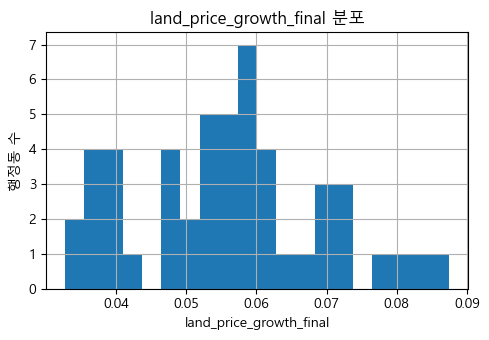

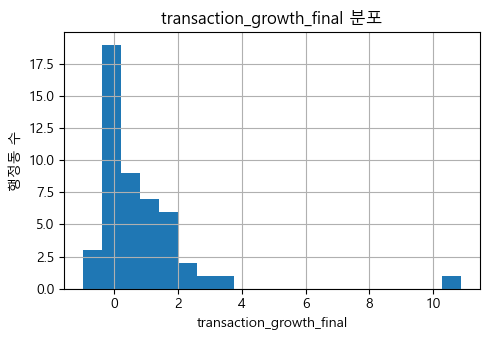

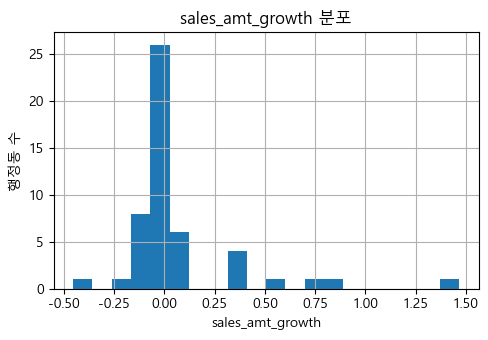

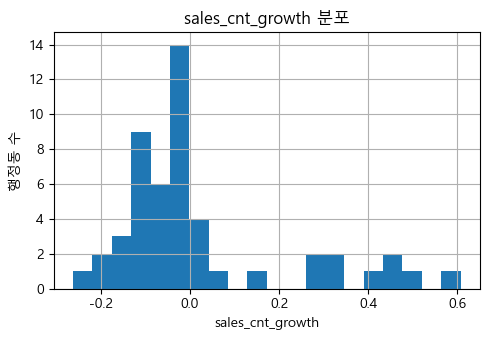

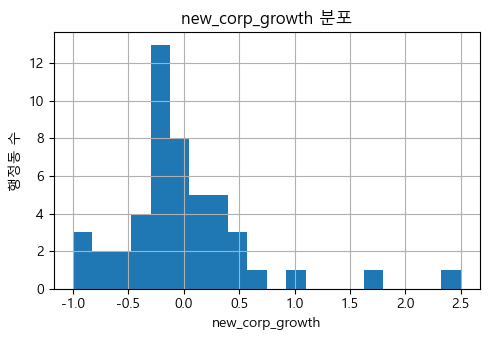

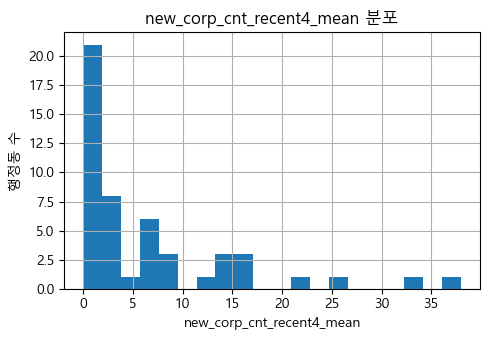

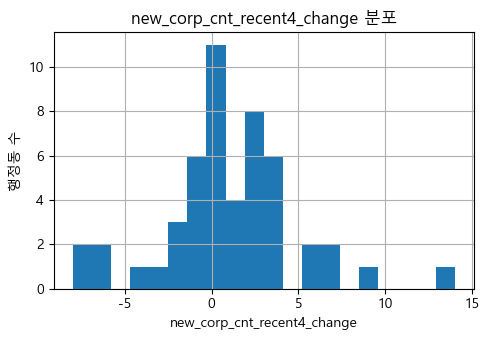

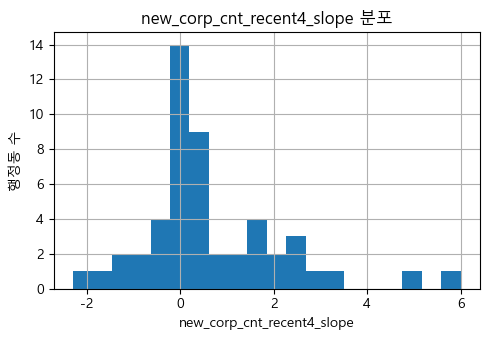

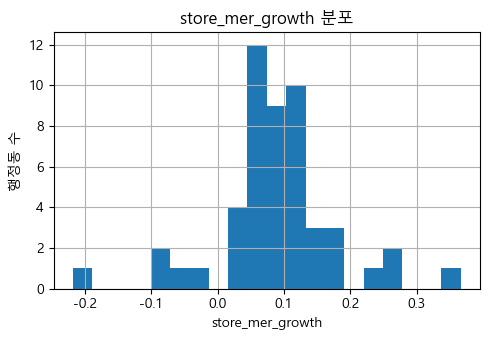

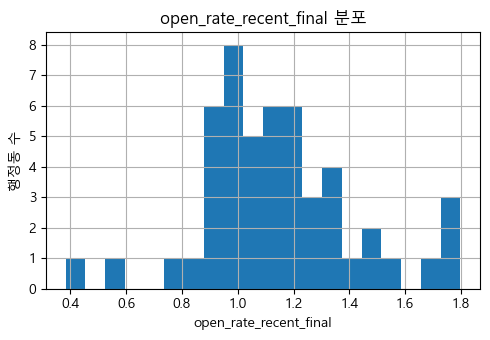

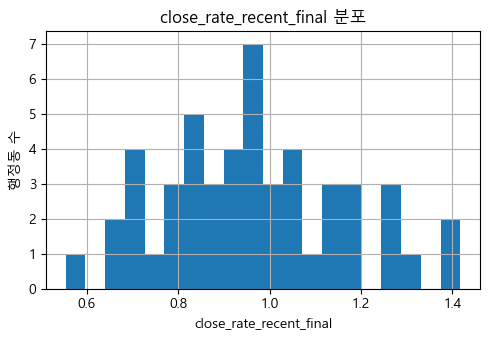

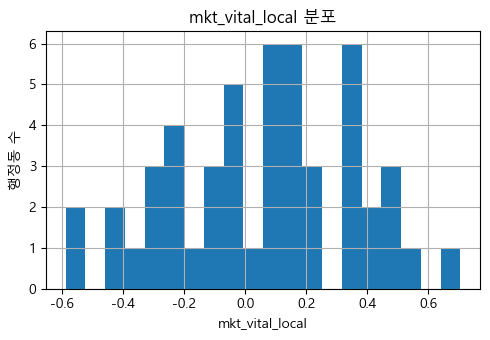

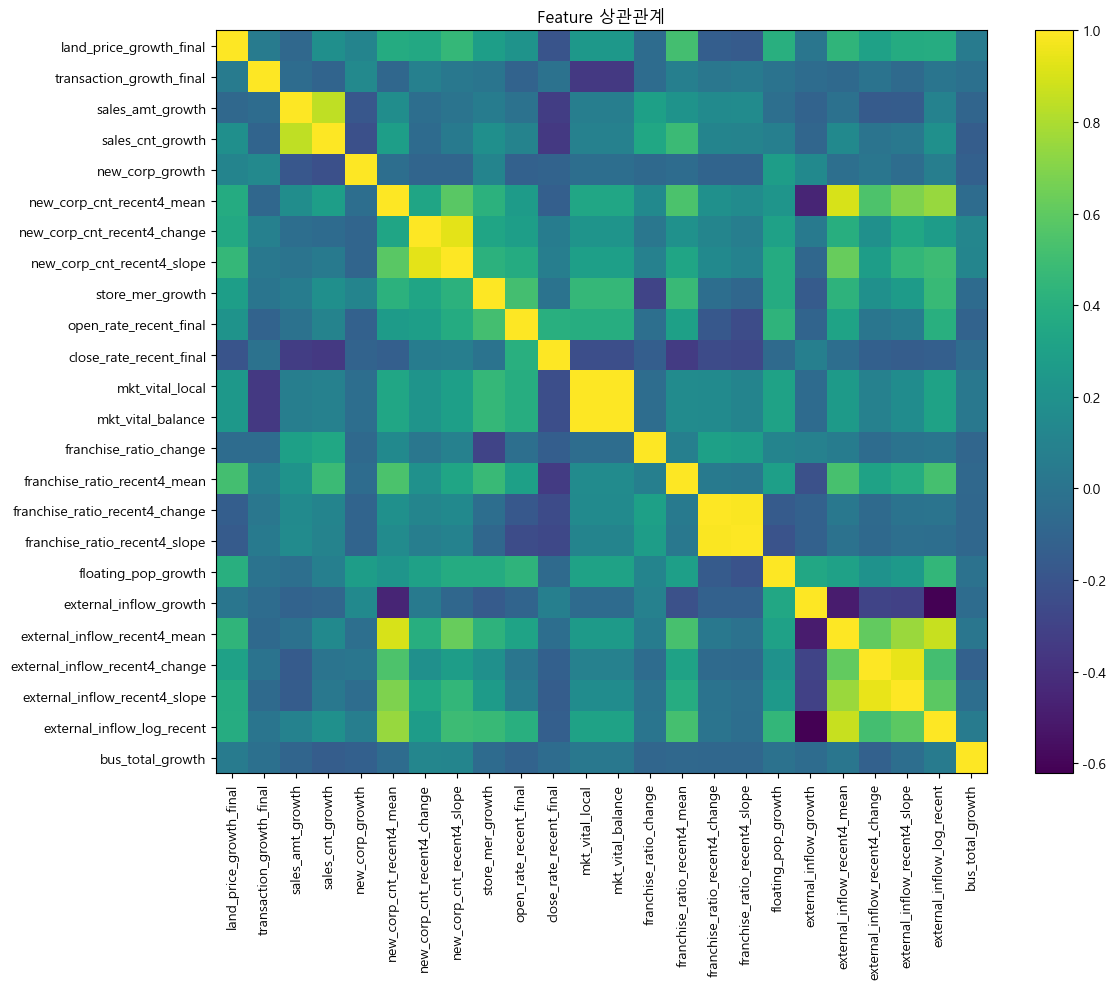

,feature_1,feature_2,corr
3,mkt_vital_local,mkt_vital_balance,1.000000
4,franchise_ratio_recent4_change,franchise_ratio_recent4_slope,0.988809
6,external_inflow_recent4_change,external_inflow_recent4_slope,0.947256
2,new_corp_cnt_recent4_change,new_corp_cnt_recent4_slope,0.934478
1,new_corp_cnt_recent4_mean,external_inflow_recent4_mean,0.902907
5,external_inflow_recent4_mean,external_inflow_log_recent,0.864751
0,sales_amt_growth,sales_cnt_growth,0.843926


결측률 기준 통과 feature 수: 24
['land_price_growth_final', 'transaction_growth_final', 'sales_amt_growth', 'sales_cnt_growth', 'new_corp_growth', 'new_corp_cnt_recent4_mean', 'new_corp_cnt_recent4_change', 'new_corp_cnt_recent4_slope', 'store_mer_growth', 'open_rate_recent_final', 'close_rate_recent_final', 'mkt_vital_local', 'mkt_vital_balance', 'franchise_ratio_change', 'franchise_ratio_recent4_mean', 'franchise_ratio_recent4_change', 'franchise_ratio_recent4_slope', 'floating_pop_growth', 'external_inflow_growth', 'external_inflow_recent4_mean', 'external_inflow_recent4_change', 'external_inflow_recent4_slope', 'external_inflow_log_recent', 'bus_total_growth']


mkt_vital_balance                      0.002988
land_price_growth_final                0.013300
store_mer_growth                       0.093691
franchise_ratio_recent4_slope          0.094867
floating_pop_growth                    0.124228
sales_cnt_growth                       0.196825
close_rate_recent_final                0.197848
external_inflow_growth                 0.233316
open_rate_recent_final                 0.278240
franchise_ratio_recent4_change         0.297323
mkt_vital_local                        0.298818
sales_amt_growth                       0.303312
new_corp_growth                        0.602063
franchise_ratio_change                 0.951622
external_inflow_log_recent             0.969080
new_corp_cnt_recent4_slope             1.521176
transaction_growth_final               1.737284
bus_total_growth                       2.283268
franchise_ratio_recent4_mean           2.431702
new_corp_cnt_recent4_change            3.905203
new_corp_cnt_recent4_mean              8

분산 기준 통과 feature 수: 24


In [147]:
candidate_features = [
    'land_price_growth_final', 'transaction_growth_final',
    'sales_amt_growth', 'sales_cnt_growth', 'new_corp_growth',
    'new_corp_cnt_recent4_mean', 'new_corp_cnt_recent4_change', 'new_corp_cnt_recent4_slope',
    'store_mer_growth', 'open_rate_recent_final', 'close_rate_recent_final',
    'mkt_vital_local', 'mkt_vital_balance',
    'franchise_ratio_change', 'franchise_ratio_recent4_mean', 'franchise_ratio_recent4_change', 'franchise_ratio_recent4_slope',
    'floating_pop_growth', 'external_inflow_growth', 'external_inflow_recent4_mean', 'external_inflow_recent4_change',
    'external_inflow_recent4_slope', 'external_inflow_log_recent',
    'bus_total_growth'
]
available_features = [col for col in candidate_features if col in dong_feature.columns]
print('군집 후보 feature 수:', len(available_features))
print(available_features)

feature_missing = pd.DataFrame({
    'feature': available_features,
    'missing_rate': [dong_feature[col].isna().mean() for col in available_features],
    'missing_count': [dong_feature[col].isna().sum() for col in available_features]
}).sort_values('missing_rate', ascending=False)

display(feature_missing)
display(dong_feature[available_features].describe().T)

plot_features = available_features[:12]
for col in plot_features:
    plt.figure(figsize=(5, 3.5))
    dong_feature[col].hist(bins=20)
    plt.title(f'{col} 분포')
    plt.xlabel(col)
    plt.ylabel('행정동 수')
    plt.tight_layout()
    plt.show()

corr = dong_feature[available_features].corr(numeric_only=True)
plt.figure(figsize=(12, 10))
plt.imshow(corr, aspect='auto')
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)), corr.index)
plt.title('Feature 상관관계')
plt.tight_layout()
plt.show()

high_corr_pairs = []
for i in range(len(corr.columns)):
    for j in range(i + 1, len(corr.columns)):
        c = corr.iloc[i, j]
        if abs(c) >= 0.8:
            high_corr_pairs.append({'feature_1': corr.columns[i], 'feature_2': corr.columns[j], 'corr': c})
high_corr_df = pd.DataFrame(high_corr_pairs)
if not high_corr_df.empty:
    high_corr_df = high_corr_df.sort_values('corr', key=lambda s: s.abs(), ascending=False)
display(high_corr_df)

missing_threshold = 0.30
features_after_missing = [col for col in available_features if dong_feature[col].isna().mean() < missing_threshold]
print('결측률 기준 통과 feature 수:', len(features_after_missing))
print(features_after_missing)

temp = dong_feature[features_after_missing].copy()
temp = temp.fillna(temp.median(numeric_only=True))
std_table = temp.std().sort_values()
display(std_table)
features_after_variance = [col for col in features_after_missing if temp[col].std() > 0]
print('분산 기준 통과 feature 수:', len(features_after_variance))

In [148]:
feature_priority = [
    'land_price_growth_final', 'transaction_growth_final', 
    'mkt_vital_balance', 'mkt_vital_local',
    'franchise_ratio_recent4_mean',
    'franchise_ratio_change', 'bus_total_growth',
    'new_corp_growth', 
    'external_inflow_log_recent', 'external_inflow_recent4_mean', 
    'close_rate_recent_final', 'open_rate_recent_final','floating_pop_growth', 
    'external_inflow_growth',
    'external_inflow_recent4_slope', 
    'sales_cnt_growth', 'store_mer_growth', 'sales_amt_growth',
    'new_corp_cnt_recent4_mean', 'new_corp_cnt_recent4_slope',
]

def remove_high_corr_features(data, features, priority_list, threshold=0.8):
    selected = features.copy()
    priority_rank = {feature: i for i, feature in enumerate(priority_list)}
    def get_rank(feature):
        return priority_rank.get(feature, 999)
    changed = True
    while changed:
        changed = False
        corr_matrix = data[selected].corr().abs()
        for i in range(len(selected)):
            for j in range(i + 1, len(selected)):
                f1 = selected[i]
                f2 = selected[j]
                if corr_matrix.loc[f1, f2] >= threshold:
                    remove_feature = f1 if get_rank(f1) > get_rank(f2) else f2
                    selected.remove(remove_feature)
                    print(f'상관 높음: {f1} vs {f2} -> 제거: {remove_feature}')
                    changed = True
                    break
            if changed:
                break
    return selected

corr_input = dong_feature[features_after_variance].copy().fillna(temp.median(numeric_only=True))
selected_features = remove_high_corr_features(corr_input, features_after_variance, feature_priority, threshold=0.8)
selected_features_sorted = sorted(selected_features, key=lambda x: feature_priority.index(x) if x in feature_priority else 999)
final_features = selected_features_sorted[:10]

print('최종 K-Means 입력 feature:')
for feature in final_features:
    print('-', feature)

상관 높음: sales_amt_growth vs sales_cnt_growth -> 제거: sales_amt_growth
상관 높음: new_corp_cnt_recent4_mean vs external_inflow_recent4_mean -> 제거: new_corp_cnt_recent4_mean
상관 높음: new_corp_cnt_recent4_change vs new_corp_cnt_recent4_slope -> 제거: new_corp_cnt_recent4_change
상관 높음: mkt_vital_local vs mkt_vital_balance -> 제거: mkt_vital_local
상관 높음: franchise_ratio_recent4_change vs franchise_ratio_recent4_slope -> 제거: franchise_ratio_recent4_slope
상관 높음: external_inflow_recent4_mean vs external_inflow_log_recent -> 제거: external_inflow_recent4_mean
상관 높음: external_inflow_recent4_change vs external_inflow_recent4_slope -> 제거: external_inflow_recent4_change
최종 K-Means 입력 feature:
- land_price_growth_final
- transaction_growth_final
- mkt_vital_balance
- franchise_ratio_recent4_mean
- franchise_ratio_change
- bus_total_growth
- new_corp_growth
- external_inflow_log_recent
- close_rate_recent_final
- open_rate_recent_final


## 4. 기본 K-Means 군집

Feature Selection을 통과한 핵심 변수만 사용해 기본 K-Means를 실행합니다.

- 결측값은 중앙값으로 대체
- `StandardScaler`와 `RobustScaler`를 모두 비교
- `k=2~6` 범위를 비교
- 실루엣 스코어만 보지 않고, CH Index, DB Index, 군집 크기까지 같이 확인

=== [Winsorizing] 상하위 5% 클리핑 ===
  land_price_growth_final: 6개 클리핑  [0.0372 ~ 0.0787]
  transaction_growth_final: 6개 클리핑  [-0.4488 ~ 2.7808]
  mkt_vital_balance: 6개 클리핑  [-0.0041 ~ 0.0049]
  franchise_ratio_recent4_mean: 6개 클리핑  [3.1629 ~ 10.6284]
  franchise_ratio_change: 6개 클리핑  [-1.4037 ~ 1.4282]
  bus_total_growth: 6개 클리핑  [0.0556 ~ 1.8451]
  new_corp_growth: 6개 클리핑  [-0.8190 ~ 0.8400]
  external_inflow_log_recent: 6개 클리핑  [11.9169 ~ 14.8703]
  close_rate_recent_final: 6개 클리핑  [0.6657 ~ 1.2874]
  open_rate_recent_final: 6개 클리핑  [0.7758 ~ 1.7064]

K-Means 입력 데이터 크기: (50, 10)


,scaler,k,silhouette_score,calinski_harabasz_score,davies_bouldin_score,inertia,cluster_sizes
0,standard,2,0.134155,8.620518,2.218331,423.874607,"{0: 32, 1: 18}"
1,standard,3,0.115293,7.816907,2.127146,375.196690,"{0: 14, 1: 14, 2: 22}"
2,standard,4,0.119757,7.403641,1.881160,337.189400,"{0: 13, 1: 10, 2: 13, 3: 14}"
3,standard,5,0.109719,6.761806,1.812866,312.295160,"{0: 8, 1: 10, 2: 13, 3: 11, 4: 8}"
4,standard,6,0.116230,6.485735,1.700805,287.850076,"{0: 10, 1: 7, 2: 6, 3: 12, 4: 6, 5: 9}"
5,robust,2,0.127716,8.371912,2.290916,284.608623,"{0: 29, 1: 21}"
6,robust,3,0.128565,8.268113,1.914757,247.255536,"{0: 20, 1: 21, 2: 9}"
7,robust,4,0.160873,8.652918,1.652902,213.670116,"{0: 15, 1: 6, 2: 10, 3: 19}"
8,robust,5,0.138350,7.589660,1.610137,199.594720,"{0: 18, 1: 8, 2: 10, 3: 10, 4: 4}"
9,robust,6,0.146705,7.510104,1.470778,180.341442,"{0: 6, 1: 12, 2: 17, 3: 5, 4: 6, 5: 4}"


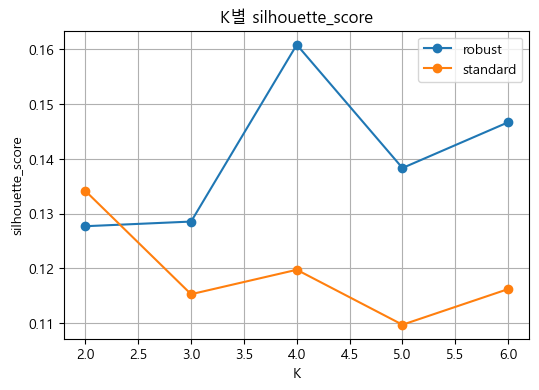

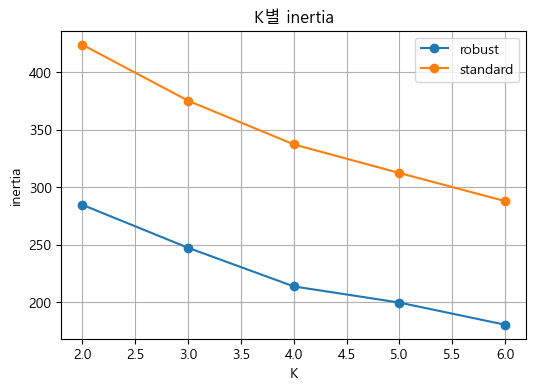

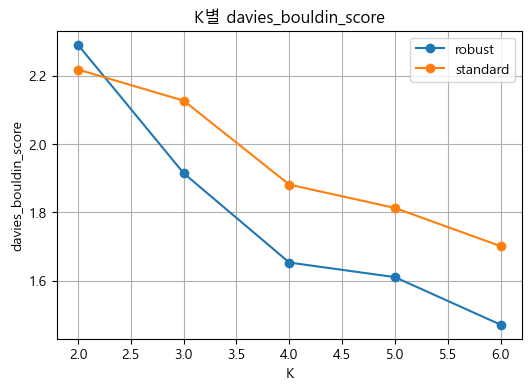

실루엣 기준 추천 K: 4
실루엣 기준 추천 스케일러: robust

[확정] 스케일러: robust  /  K: 4
기본 K-Means Silhouette: 0.1608727582288789
기본 K-Means CH Index: 8.652917686438487
기본 K-Means DB Index: 1.652901511779906


cluster_basic
0    15
1     6
2    10
3    19
Name: count, dtype: int64

land_price_growth_final                               transaction_growth_final                                mkt_vital_balance                                \
                                 mean    median       min       max                     mean    median       min        max              mean    median       min       max   
cluster_basic                                                                                                                                                                 
0                            0.060128  0.058011  0.046877  0.076940                 1.015351  0.094017 -0.338235  10.875000          0.000814  0.001632 -0.005872  0.003817   
1                            0.065082  0.064025  0.053756  0.084274                 0.493181  0.470085 -0.970588   2.494737          0.001021  0.001329 -0.003971  0.004145   
2                            0.056765  0.060976  0.032750  0.087455                 0.517391  0.277778 -0.568627   2.971429          0.001869  0.001403 -0.002099  0.004949   
3                            0.049457  0.051795  0.037420  0.067288                 0.843094  0.933333 -0.500000   2.384615         -0.000308 -0.000674 -0.005302  0.007049   

              franchise_ratio_recent4_mean                                franchise_ratio_change                               bus_total_growth                                new_corp_growth  \
                                      mean    median       min        max                   mean    median       min       max             mean    median       min        max            mean   
cluster_basic                                                                                                                                                                                    
0                                 5.698992  4.811551  4.217316   8.380154              -0.278345 -0.344885 -0.863147  0.544503         2.271131  1.255716  0.523584  16.322910       -0.174118   
1                                 8.331352  8.151121  5.183398  11.886907               1.658399  1.418057  0.698338  3.901440         0.431561  0.427981  0.287800   0.530987       -0.036845   
2                                 7.510858  6.357760  4.014527  16.300622              -0.980154 -0.738941 -1.986967 -0.207471         0.370840  0.312977  0.037411   0.660754       -0.086180   
3                                 4.648722  4.405724  2.808465   6.579875              -0.194361 -0.130983 -1.090087  1.102726         0.262244  0.209063 -0.025411   0.618592        0.191668   

                                            external_inflow_log_recent                                  close_rate_recent_final                               open_rate_recent_final            \
                 median       min       max                       mean     median        min        max                    mean    median       min       max                   mean    median   
cluster_basic                                                                                                                                                                                    
0             -0.212766 -1.000000  0.400000                  13.589498  13.600741  12.168608  15.427027                0.920643  0.915389  0.641272  1.296775               1.048007  1.006343   
1              0.071429 -0.714286  0.500000                  13.844636  14.116940  12.155148  14.982087                0.936030  0.943411  0.648634  1.176893               1.378686  1.313424   
2             -0.085714 -0.888889  0.560976                  14.139120  14.238397  13.303834  14.951489                1.033792  0.991505  0.553802  1.375820               1.443553  1.431878   
3              0.000000 -1.000000  2.500000                  12.881656  12.913658  10.873287  14.209342                0.973392  0.971746  0.702538  1.417173               0.990715  0.990485   

                                   
                    min       max 

,land_price_growth_final,transaction_growth_final,mkt_vital_balance,franchise_ratio_recent4_mean,franchise_ratio_change,bus_total_growth,new_corp_growth,external_inflow_log_recent,close_rate_recent_final,open_rate_recent_final
cluster_basic,,,,,,,,,,
0,0.060128,1.015351,0.000814,5.698992,-0.278345,2.271131,-0.174118,13.589498,0.920643,1.048007
1,0.065082,0.493181,0.001021,8.331352,1.658399,0.431561,-0.036845,13.844636,0.936030,1.378686
2,0.056765,0.517391,0.001869,7.510858,-0.980154,0.370840,-0.086180,14.139120,1.033792,1.443553
3,0.049457,0.843094,-0.000308,4.648722,-0.194361,0.262244,0.191668,12.881656,0.973392,0.990715



[기본 군집 0] 행정동 수: 15
태평2동, 태평3동, 태평4동, 분당동, 수내3동, 정자동, 정자2동, 정자3동, 서현2동, 이매2동, 야탑3동, 삼평동, 금곡동, 구미1동, 구미동

[기본 군집 1] 행정동 수: 6
신흥2동, 산성동, 시흥동, 중앙동, 정자1동, 서현1동

[기본 군집 2] 행정동 수: 10
위례동, 고등동, 성남동, 금광1동, 금광2동, 수내1동, 야탑1동, 판교동, 백현동, 운중동

[기본 군집 3] 행정동 수: 19
신흥1동, 신흥3동, 태평1동, 수진1동, 수진2동, 단대동, 양지동, 복정동, 신촌동, 은행1동, 은행2동, 상대원1동, 상대원2동, 상대원3동, 하대원동, 도촌동, 수내2동, 이매1동, 야탑2동


,feature,statistic,p_value,significant_0.05
5,bus_total_growth,31.357339,7.148106e-07,True
9,open_rate_recent_final,24.691897,1.790880e-05,True
4,franchise_ratio_change,23.385346,3.356240e-05,True
3,franchise_ratio_recent4_mean,17.409701,5.820371e-04,True
7,external_inflow_log_recent,13.198993,4.225450e-03,True
0,land_price_growth_final,9.610876,2.218062e-02,True
2,mkt_vital_balance,4.768206,1.895786e-01,False
1,transaction_growth_final,2.538275,4.684136e-01,False
6,new_corp_growth,2.494123,4.763541e-01,False
8,close_rate_recent_final,2.309531,5.106974e-01,False


In [149]:
X_raw = dong_feature[final_features].copy()

# ── [수정 1] Winsorizing: 상하위 5% 클리핑 ────────────────────────────────
# 문제: sales_amt_growth 등 증가율 변수는 분모가 작은 행정동에서 극단값이 발생하며,
#       표준편차가 다른 변수 대비 수배~수십 배 커지는 현상이 관찰됨.
#       StandardScaler 적용 후에도 z-score 4~5 수준 이상치가 K-Means 거리를
#       사실상 혼자 결정하므로, 클리핑으로 1차 이상치 영향을 제거함.
print('=== [Winsorizing] 상하위 5% 클리핑 ===')
for win_col in final_features:
    lo = X_raw[win_col].quantile(0.05)
    hi = X_raw[win_col].quantile(0.95)
    n_clipped = ((X_raw[win_col] < lo) | (X_raw[win_col] > hi)).sum()
    if n_clipped > 0:
        print(f'  {win_col}: {n_clipped}개 클리핑  [{lo:.4f} ~ {hi:.4f}]')
    X_raw[win_col] = X_raw[win_col].clip(lower=lo, upper=hi)

imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X_raw)

standard_scaler = StandardScaler()
X_scaled = standard_scaler.fit_transform(X_imputed)

robust_scaler = RobustScaler()
X_scaled_robust = robust_scaler.fit_transform(X_imputed)

print('\nK-Means 입력 데이터 크기:', X_scaled.shape)

k_results = []
for scaler_name, X_input in [('standard', X_scaled), ('robust', X_scaled_robust)]:
    for k in range(2, 7):
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
        labels = kmeans.fit_predict(X_input)
        k_results.append({
            'scaler': scaler_name,
            'k': k,
            'silhouette_score': silhouette_score(X_input, labels),
            'calinski_harabasz_score': calinski_harabasz_score(X_input, labels),
            'davies_bouldin_score': davies_bouldin_score(X_input, labels),
            'inertia': kmeans.inertia_,
            'cluster_sizes': pd.Series(labels).value_counts().sort_index().to_dict()
        })

k_result_df = pd.DataFrame(k_results)
display(k_result_df)

for metric in ['silhouette_score', 'inertia', 'davies_bouldin_score']:
    plt.figure(figsize=(6, 4))
    for scaler_name, temp_df in k_result_df.groupby('scaler'):
        plt.plot(temp_df['k'], temp_df[metric], marker='o', label=scaler_name)
    plt.title(f'K별 {metric}')
    plt.xlabel('K')
    plt.ylabel(metric)
    plt.grid(True)
    plt.legend()
    plt.show()

recommended_row = k_result_df.sort_values('silhouette_score', ascending=False).iloc[0]
best_k_by_silhouette = int(recommended_row['k'])
best_scaler_by_silhouette = recommended_row['scaler']
print('실루엣 기준 추천 K:', best_k_by_silhouette)
print('실루엣 기준 추천 스케일러:', best_scaler_by_silhouette)

# ── [수정 2] RobustScaler 강제 고정 ──────────────────────────────────────
# 문제: 실루엣 자동 선택 시 StandardScaler가 채택되면, Winsorizing 이후에도
#       잔존 이상치가 유클리드 거리를 지배할 가능성이 남음.
#       RobustScaler는 중앙값(median)·IQR 기반이므로 이상치 영향을
#       StandardScaler보다 근본적으로 줄여줌.
# 결론: Winsorizing + RobustScaler 조합으로 이상치 대응을 이중화함.
final_k_basic = best_k_by_silhouette
final_scaler_basic = 'robust'   # 이상치 대응: 실루엣 자동 선택 대신 RobustScaler 강제 고정
X_scaled_final_basic = X_scaled_robust
print(f'\n[확정] 스케일러: {final_scaler_basic}  /  K: {final_k_basic}')

basic_kmeans = KMeans(n_clusters=final_k_basic, random_state=42, n_init=20)
dong_feature['cluster_basic'] = basic_kmeans.fit_predict(X_scaled_final_basic)

basic_silhouette = silhouette_score(X_scaled_final_basic, dong_feature['cluster_basic'])
basic_ch = calinski_harabasz_score(X_scaled_final_basic, dong_feature['cluster_basic'])
basic_db = davies_bouldin_score(X_scaled_final_basic, dong_feature['cluster_basic'])

print('기본 K-Means Silhouette:', basic_silhouette)
print('기본 K-Means CH Index:', basic_ch)
print('기본 K-Means DB Index:', basic_db)
display(dong_feature['cluster_basic'].value_counts().sort_index())

basic_profile = dong_feature.groupby('cluster_basic')[final_features].agg(['mean', 'median', 'min', 'max'])
basic_profile_mean = dong_feature.groupby('cluster_basic')[final_features].mean()
display(basic_profile)
display(basic_profile_mean)

for cluster_id in sorted(dong_feature['cluster_basic'].unique()):
    temp_df = dong_feature[dong_feature['cluster_basic'] == cluster_id]
    print(f'\n[기본 군집 {cluster_id}] 행정동 수: {len(temp_df)}')
    print(', '.join(temp_df[adm_nm_col].tolist()))

kruskal_results = []
for col in final_features:
    groups = []
    for cluster_id in sorted(dong_feature['cluster_basic'].unique()):
        values = dong_feature[dong_feature['cluster_basic'] == cluster_id][col].dropna()
        if len(values) > 0:
            groups.append(values)
    if len(groups) >= 2:
        stat, p_value = kruskal(*groups)
        kruskal_results.append({'feature': col, 'statistic': stat, 'p_value': p_value, 'significant_0.05': p_value < 0.05})
kruskal_df = pd.DataFrame(kruskal_results).sort_values('p_value')
display(kruskal_df)

## 5. 도메인 점수 기반 가중합 K-Means

이 단계에서는 세부 feature를 바로 쓰지 않고, 상권·부동산·인구·교통의 메인 점수를 만든 뒤 가중합 score를 계산합니다.

이 모델은 원시 feature에 직접 가중치를 주는 방식이 아니라, **도메인별 score를 만든 뒤 그 점수로 군집화하는 모델**입니다.

따라서 기본 K-Means와는 역할이 다릅니다.

- 기본 K-Means: 데이터가 자연스럽게 나뉘는 구조 확인
- 도메인 점수 기반 모델: 분석자의 해석 관점을 반영한 구조 확인

In [150]:
commerce_features = [
    'sales_amt_growth', 'close_rate_recent_final', 'franchise_ratio_change', 'new_corp_growth',
    'new_corp_cnt_recent4_mean', 'new_corp_cnt_recent4_slope', 'open_rate_recent_final',
    'mkt_vital_local', 'mkt_vital_balance'
]
real_estate_features = ['land_price_growth_final', 'transaction_growth_final']
population_features = [
    'floating_pop_growth', 'external_inflow_growth', 'external_inflow_recent4_mean',
    'external_inflow_recent4_slope', 'external_inflow_log_recent'
]
transport_features = ['bus_total_growth']

feature_groups = {
    'commerce_score': [f for f in commerce_features if f in dong_feature.columns],
    'real_estate_score': [f for f in real_estate_features if f in dong_feature.columns],
    'population_score': [f for f in population_features if f in dong_feature.columns],
    'transport_score': [f for f in transport_features if f in dong_feature.columns]
}
display(feature_groups)


def make_group_score(data, features, score_name):
    if len(features) == 0:
        print(f'{score_name}: 사용할 feature가 없어 생성하지 않습니다.')
        return None
    X = data[features].copy().replace([np.inf, -np.inf], np.nan)
    imputer_local = SimpleImputer(strategy='median')
    X_imputed_local = imputer_local.fit_transform(X)
    scaler_local = StandardScaler()
    X_scaled_local = scaler_local.fit_transform(X_imputed_local)
    score = X_scaled_local.mean(axis=1)
    print(f'{score_name} 생성 완료 / 사용 feature: {features}')
    return score

for score_name, features in feature_groups.items():
    score = make_group_score(dong_feature, features, score_name)
    if score is not None:
        dong_feature[score_name] = score

base_weights = {
    'commerce_score': 0.35,
    'real_estate_score': 0.30,
    'population_score': 0.25,
    'transport_score': 0.10
}
available_score_cols = [col for col in base_weights.keys() if col in dong_feature.columns]
available_weight_sum = sum(base_weights[col] for col in available_score_cols)
normalized_weights = {col: base_weights[col] / available_weight_sum for col in available_score_cols}
print('사용 가능한 메인 점수:', available_score_cols)
print('보정된 가중치:', normalized_weights)

for col, weight in normalized_weights.items():
    dong_feature[col + '_weighted'] = dong_feature[col] * weight
weighted_score_cols = [col + '_weighted' for col in available_score_cols]
dong_feature['gentrification_weighted_score'] = dong_feature[weighted_score_cols].sum(axis=1)

display(dong_feature[[adm_nm_col] + available_score_cols + ['gentrification_weighted_score']].head())

weighted_input_cols = weighted_score_cols
X_weighted_raw = dong_feature[weighted_input_cols].copy()
imputer_weighted = SimpleImputer(strategy='median')
X_weighted_imputed = imputer_weighted.fit_transform(X_weighted_raw)
scaler_weighted = StandardScaler()
X_weighted_scaled = scaler_weighted.fit_transform(X_weighted_imputed)

weighted_k_results = []
for k in range(2, 7):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = kmeans.fit_predict(X_weighted_scaled)
    weighted_k_results.append({
        'k': k,
        'silhouette_score': silhouette_score(X_weighted_scaled, labels),
        'calinski_harabasz_score': calinski_harabasz_score(X_weighted_scaled, labels),
        'davies_bouldin_score': davies_bouldin_score(X_weighted_scaled, labels),
        'inertia': kmeans.inertia_,
        'cluster_sizes': pd.Series(labels).value_counts().sort_index().to_dict()
    })
weighted_k_result_df = pd.DataFrame(weighted_k_results)
display(weighted_k_result_df)

best_k_weighted = int(weighted_k_result_df.sort_values('silhouette_score', ascending=False).iloc[0]['k'])
print('도메인 점수 기반 모델 추천 K:', best_k_weighted)
final_k_weighted = best_k_weighted

weighted_kmeans = KMeans(n_clusters=final_k_weighted, random_state=42, n_init=20)
dong_feature['cluster_weighted'] = weighted_kmeans.fit_predict(X_weighted_scaled)
weighted_silhouette = silhouette_score(X_weighted_scaled, dong_feature['cluster_weighted'])
weighted_ch = calinski_harabasz_score(X_weighted_scaled, dong_feature['cluster_weighted'])
weighted_db = davies_bouldin_score(X_weighted_scaled, dong_feature['cluster_weighted'])
print('도메인 점수 기반 K-Means Silhouette:', weighted_silhouette)
print('도메인 점수 기반 K-Means CH Index:', weighted_ch)
print('도메인 점수 기반 K-Means DB Index:', weighted_db)

weighted_profile_mean = dong_feature.groupby('cluster_weighted')[available_score_cols + ['gentrification_weighted_score']].mean()
display(weighted_profile_mean)
for cluster_id in sorted(dong_feature['cluster_weighted'].unique()):
    temp_df = dong_feature[dong_feature['cluster_weighted'] == cluster_id]
    print(f'\n[도메인 점수 군집 {cluster_id}] 행정동 수: {len(temp_df)}')
    print(', '.join(temp_df[adm_nm_col].tolist()))

{'commerce_score': ['sales_amt_growth',
  'close_rate_recent_final',
  'franchise_ratio_change',
  'new_corp_growth',
  'new_corp_cnt_recent4_mean',
  'new_corp_cnt_recent4_slope',
  'open_rate_recent_final',
  'mkt_vital_local',
  'mkt_vital_balance'],
 'real_estate_score': ['land_price_growth_final', 'transaction_growth_final'],
 'population_score': ['floating_pop_growth',
  'external_inflow_growth',
  'external_inflow_recent4_mean',
  'external_inflow_recent4_slope',
  'external_inflow_log_recent'],
 'transport_score': ['bus_total_growth']}

commerce_score 생성 완료 / 사용 feature: ['sales_amt_growth', 'close_rate_recent_final', 'franchise_ratio_change', 'new_corp_growth', 'new_corp_cnt_recent4_mean', 'new_corp_cnt_recent4_slope', 'open_rate_recent_final', 'mkt_vital_local', 'mkt_vital_balance']
real_estate_score 생성 완료 / 사용 feature: ['land_price_growth_final', 'transaction_growth_final']
population_score 생성 완료 / 사용 feature: ['floating_pop_growth', 'external_inflow_growth', 'external_inflow_recent4_mean', 'external_inflow_recent4_slope', 'external_inflow_log_recent']
transport_score 생성 완료 / 사용 feature: ['bus_total_growth']
사용 가능한 메인 점수: ['commerce_score', 'real_estate_score', 'population_score', 'transport_score']
보정된 가중치: {'commerce_score': 0.35000000000000003, 'real_estate_score': 0.30000000000000004, 'population_score': 0.25000000000000006, 'transport_score': 0.10000000000000002}


,adm_dong_nm,commerce_score,real_estate_score,population_score,transport_score,gentrification_weighted_score
0,신흥1동,-0.259106,-0.058988,-0.657864,-0.386088,-0.311458
1,신흥2동,0.387010,-0.058988,1.154740,-0.225968,0.383845
2,신흥3동,-0.193700,-0.058988,-0.329860,-0.355538,-0.203510
3,태평1동,-0.386800,-0.431485,-0.043548,-0.131609,-0.288873
4,태평2동,-0.391809,-0.431485,-0.523223,0.034938,-0.393891


,k,silhouette_score,calinski_harabasz_score,davies_bouldin_score,inertia,cluster_sizes
0,2,0.315693,17.979816,1.289544,145.499042,"{0: 33, 1: 17}"
1,3,0.340166,24.319582,0.869978,98.286096,"{0: 32, 1: 17, 2: 1}"
2,4,0.328360,26.369171,0.867991,73.536751,"{0: 17, 1: 26, 2: 6, 3: 1}"
3,5,0.263969,26.426788,0.929426,59.718466,"{0: 22, 1: 1, 2: 5, 3: 16, 4: 6}"
4,6,0.253154,26.603173,0.863369,49.713058,"{0: 6, 1: 19, 2: 13, 3: 6, 4: 1, 5: 5}"


도메인 점수 기반 모델 추천 K: 3
도메인 점수 기반 K-Means Silhouette: 0.3401660279955693
도메인 점수 기반 K-Means CH Index: 24.31958173107437
도메인 점수 기반 K-Means DB Index: 0.8699779446401937


,commerce_score,real_estate_score,population_score,transport_score,gentrification_weighted_score
cluster_weighted,,,,,
0,-0.171376,-0.313782,-0.302421,-0.141857,-0.243907
1,0.333038,0.597826,0.570871,-0.133930,0.425236
2,-0.177627,-0.122027,-0.027341,6.816220,0.576009



[도메인 점수 군집 0] 행정동 수: 32
신흥1동, 신흥3동, 태평1동, 태평2동, 태평3동, 태평4동, 수진1동, 수진2동, 단대동, 산성동, 양지동, 신촌동, 고등동, 성남동, 중앙동, 금광1동, 금광2동, 은행1동, 은행2동, 상대원2동, 상대원3동, 하대원동, 도촌동, 수내1동, 수내3동, 정자2동, 정자3동, 서현2동, 이매1동, 이매2동, 야탑2동, 야탑3동

[도메인 점수 군집 1] 행정동 수: 17
신흥2동, 복정동, 위례동, 시흥동, 상대원1동, 분당동, 수내2동, 정자1동, 서현1동, 야탑1동, 판교동, 삼평동, 백현동, 금곡동, 구미1동, 구미동, 운중동

[도메인 점수 군집 2] 행정동 수: 1
정자동


## 6. 모델 비교, PCA, 최종 해석, CSV 저장

기본 K-Means는 데이터가 자연스럽게 나뉘는 구조를 보여줍니다. 반면 도메인 점수 기반 가중합 K-Means는 상권 변화와 부동산 압력을 더 중요하게 반영한 분석자의 관점이 들어간 모델입니다.

따라서 최종 모델은 실루엣 스코어가 더 높은지뿐 아니라, 군집별 행정동 목록과 군집별 평균값이 성남시 지역 특성과 정책 해석에 잘 맞는지를 함께 보고 선택해야 합니다.

PCA는 시각화 보조 도구이며, PCA 축 자체를 젠트리피케이션 중요도라고 해석하면 안 됩니다.

,model,k,scaler,input_features,silhouette_score,calinski_harabasz_score,davies_bouldin_score,cluster_sizes
0,basic_kmeans,4,robust,"land_price_growth_final, transaction_growth_fi...",0.160873,8.652918,1.652902,"{0: 15, 1: 6, 2: 10, 3: 19}"
1,weighted_kmeans,3,standard,"commerce_score_weighted, real_estate_score_wei...",0.340166,24.319582,0.869978,"{0: 32, 1: 17, 2: 1}"


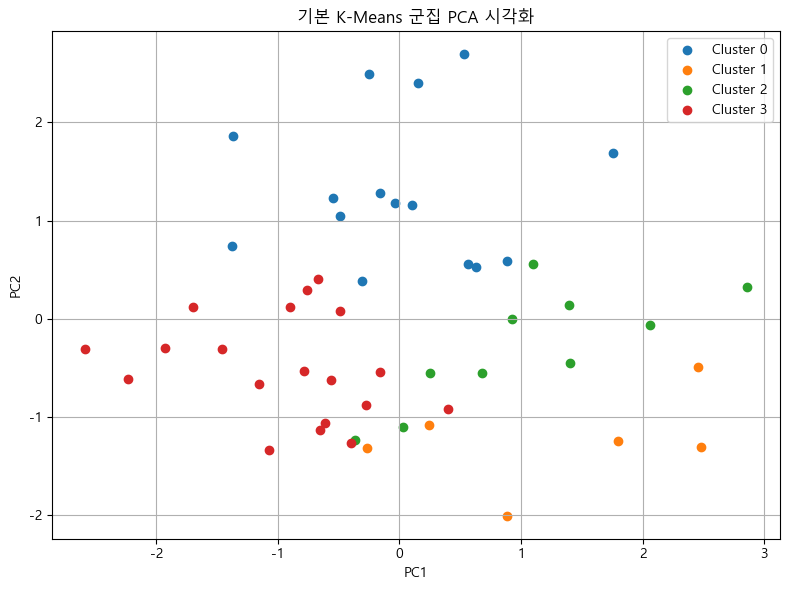

PCA 설명 분산 비율: [0.21520555 0.17466917]

===== cluster_basic / Cluster 0 =====
행정동 수: 15

상대적으로 높은 지표:
bus_total_growth              1.325343
transaction_growth_final      0.228842
external_inflow_log_recent    0.128439
Name: 0, dtype: float64

상대적으로 낮은 지표:
franchise_ratio_recent4_mean   -0.279154
new_corp_growth                -0.173790
franchise_ratio_change         -0.123961
Name: 0, dtype: float64

===== cluster_basic / Cluster 1 =====
행정동 수: 6

상대적으로 높은 지표:
franchise_ratio_recent4_mean    2.353206
franchise_ratio_change          1.812783
external_inflow_log_recent      0.383577
Name: 1, dtype: float64

상대적으로 낮은 지표:
bus_total_growth           -0.514227
transaction_growth_final   -0.293328
new_corp_growth            -0.036516
Name: 1, dtype: float64

===== cluster_basic / Cluster 2 =====
행정동 수: 10

상대적으로 높은 지표:
franchise_ratio_recent4_mean    1.532712
external_inflow_log_recent      0.678061
open_rate_recent_final          0.298526
Name: 2, dtype: float64

상대적으로 낮은 지표:
franchise_ratio


## 최종 해석 방향

본 분석에서는 성남시 행정동별 젠트리피케이션 진행 양상을 K-Means로 탐색적으로 유형화하였다.

기본 K-Means는 feature selection을 거친 핵심 지표를 바탕으로 데이터가 자연스럽게 나뉘는 구조를 확인하는 데 사용하였다. 도메인 점수 기반 가중합 K-Means는 상권 특성, 부동산, 인구, 교통이라는 네 가지 메인 지표에 중요도를 부여하여 젠트리피케이션 판단 관점을 반영한 모델이다.

또한 증가율 변수는 작은 분모 문제를 가질 수 있으므로, 최근 4분기 평균, 최근 4분기 변화량, 최근 추세 slope 같은 보조 지표를 함께 활용하였다.

기본 모델의 Silhouette Score는 0.1609, 도메인 점수 기반 모델의 Silhouette Score는 0.3402로 계산되었다. 최종적으로는 실루엣 스코어가 가장 높은 모델을 무조건 선택하기보다, 성남시 지역 특성과 정책적 해석 가능성이 가장 높은 모델을 선택하는 것이 적절하다.

## 보고서 작성 예시

본 연구는 성남시 행정동별 상권 변화, 인구 유입, 교통 접근성 지표를 활용하여 젠트리피케이션 진행 양상이 유사한 지역을 군집화하였다. 분석 결과, 일부 군집은 매출 증가와 외부 유입 증가가 두드러졌고, 일부 군집은 폐업률과 프랜차이즈 비율 변화가 상대적으로 높게 나타났다.

이는 성남시 내에서도 모든 지역이 동일한 방식으로 변화하는 것이 아니라, 상권 성장형, 상권 교체형, 안정형, 잠재 변화형 등 서로 다른 변화 양상이 존재함을 보여준다. 다만 본 분석은 정답 라벨이 없는 탐색적 군집 분석이므로, 결과를 위험지역의 확정적 판정으로 해석하기보다는 정책 우선 검토 지역을 선별하기 위한 보조 지표로 활용하는 것이 적절하다.

## 분석 시 주의사항

1. K-Means는 정답 라벨이 없는 비지도학습이므로 정확도라는 표현은 사용하지 않는다.
2. 실루엣 스코어는 군집 품질을 보는 참고 지표이며, 정책적 해석 가능성과 함께 봐야 한다.
3. 600개 행정동-분기 데이터를 그대로 군집화하지 않고, 행정동 단위 변화 지표를 만든 뒤 군집화하였다.
4. YoY 기반 변수는 2023년 구조적 결측이 생길 수 있으므로, 2023년 관측치와 missing flag를 군집 feature에 직접 넣지 않는 방향을 우선 검토해야 한다.
5. 결측값을 0으로 채우지 않고, 중앙값 대체 또는 feature 제외 방식으로 처리하였다.
6. 증가율 변수는 작은 분모에서 과도하게 커질 수 있으므로, 최근 평균·최근 변화량·최근 추세 slope와 함께 해석해야 한다.
7. 상권활력도는 전체 기간 대비 비중뿐 아니라, 지역 내부 기준 지표도 함께 검토해야 한다.
8. 부동산 지표가 없으면 본 결과는 젠트리피케이션 전체 모델이 아니라 상권·인구·교통 기반 탐색 모델로 해석해야 한다.
9. 도메인 점수 기반 가중합 모델은 분석자의 판단이 반영된 모델이므로, 기본 모델과 반드시 비교해야 한다.
10. PCA는 시각화 보조 도구이며, PCA 축을 변수 중요도로 직접 해석하면 안 된다.


결과 저장 완료
output\dong_feature_table_with_clusters.csv
output\basic_kmeans_k_comparison.csv
output\weighted_kmeans_k_comparison.csv
output\model_comparison_summary.csv
output\basic_cluster_kruskal_test.csv


In [151]:
comparison_summary = pd.DataFrame([
    {
        'model': 'basic_kmeans',
        'k': final_k_basic,
        'scaler': final_scaler_basic,
        'input_features': ', '.join(final_features),
        'silhouette_score': basic_silhouette,
        'calinski_harabasz_score': basic_ch,
        'davies_bouldin_score': basic_db,
        'cluster_sizes': dong_feature['cluster_basic'].value_counts().sort_index().to_dict()
    },
    {
        'model': 'weighted_kmeans',
        'k': final_k_weighted,
        'scaler': 'standard',
        'input_features': ', '.join(weighted_input_cols),
        'silhouette_score': weighted_silhouette,
        'calinski_harabasz_score': weighted_ch,
        'davies_bouldin_score': weighted_db,
        'cluster_sizes': dong_feature['cluster_weighted'].value_counts().sort_index().to_dict()
    }
])
display(comparison_summary)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled_final_basic)
pca_df = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'cluster_basic': dong_feature['cluster_basic'],
    'adm_dong_nm': dong_feature[adm_nm_col]
})

plt.figure(figsize=(8, 6))
for cluster_id in sorted(pca_df['cluster_basic'].unique()):
    temp_df = pca_df[pca_df['cluster_basic'] == cluster_id]
    plt.scatter(temp_df['PC1'], temp_df['PC2'], label=f'Cluster {cluster_id}')
plt.title('기본 K-Means 군집 PCA 시각화')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
print('PCA 설명 분산 비율:', pca.explained_variance_ratio_)


def show_cluster_profile_for_interpretation(data, cluster_col, features):
    overall_mean = data[features].mean()
    cluster_mean = data.groupby(cluster_col)[features].mean()
    diff = cluster_mean - overall_mean
    for cluster_id in diff.index:
        print(f'\n===== {cluster_col} / Cluster {cluster_id} =====')
        print('행정동 수:', (data[cluster_col] == cluster_id).sum())
        print('\n상대적으로 높은 지표:')
        print(diff.loc[cluster_id].sort_values(ascending=False).head(3))
        print('\n상대적으로 낮은 지표:')
        print(diff.loc[cluster_id].sort_values(ascending=True).head(3))

show_cluster_profile_for_interpretation(dong_feature, 'cluster_basic', final_features)
show_cluster_profile_for_interpretation(dong_feature, 'cluster_weighted', available_score_cols + ['gentrification_weighted_score'])

dong_feature.to_csv(OUTPUT_DIR / 'dong_feature_table_with_clusters.csv', index=False, encoding='utf-8-sig')
k_result_df.to_csv(OUTPUT_DIR / 'basic_kmeans_k_comparison.csv', index=False, encoding='utf-8-sig')
weighted_k_result_df.to_csv(OUTPUT_DIR / 'weighted_kmeans_k_comparison.csv', index=False, encoding='utf-8-sig')
comparison_summary.to_csv(OUTPUT_DIR / 'model_comparison_summary.csv', index=False, encoding='utf-8-sig')
kruskal_df.to_csv(OUTPUT_DIR / 'basic_cluster_kruskal_test.csv', index=False, encoding='utf-8-sig')

final_md = f"""
## 최종 해석 방향

본 분석에서는 성남시 행정동별 젠트리피케이션 진행 양상을 K-Means로 탐색적으로 유형화하였다.

기본 K-Means는 feature selection을 거친 핵심 지표를 바탕으로 데이터가 자연스럽게 나뉘는 구조를 확인하는 데 사용하였다. 도메인 점수 기반 가중합 K-Means는 상권 특성, 부동산, 인구, 교통이라는 네 가지 메인 지표에 중요도를 부여하여 젠트리피케이션 판단 관점을 반영한 모델이다.

또한 증가율 변수는 작은 분모 문제를 가질 수 있으므로, 최근 4분기 평균, 최근 4분기 변화량, 최근 추세 slope 같은 보조 지표를 함께 활용하였다.

기본 모델의 Silhouette Score는 {basic_silhouette:.4f}, 도메인 점수 기반 모델의 Silhouette Score는 {weighted_silhouette:.4f}로 계산되었다. 최종적으로는 실루엣 스코어가 가장 높은 모델을 무조건 선택하기보다, 성남시 지역 특성과 정책적 해석 가능성이 가장 높은 모델을 선택하는 것이 적절하다.

## 보고서 작성 예시

본 연구는 성남시 행정동별 상권 변화, 인구 유입, 교통 접근성 지표를 활용하여 젠트리피케이션 진행 양상이 유사한 지역을 군집화하였다. 분석 결과, 일부 군집은 매출 증가와 외부 유입 증가가 두드러졌고, 일부 군집은 폐업률과 프랜차이즈 비율 변화가 상대적으로 높게 나타났다.

이는 성남시 내에서도 모든 지역이 동일한 방식으로 변화하는 것이 아니라, 상권 성장형, 상권 교체형, 안정형, 잠재 변화형 등 서로 다른 변화 양상이 존재함을 보여준다. 다만 본 분석은 정답 라벨이 없는 탐색적 군집 분석이므로, 결과를 위험지역의 확정적 판정으로 해석하기보다는 정책 우선 검토 지역을 선별하기 위한 보조 지표로 활용하는 것이 적절하다.

## 분석 시 주의사항

1. K-Means는 정답 라벨이 없는 비지도학습이므로 정확도라는 표현은 사용하지 않는다.
2. 실루엣 스코어는 군집 품질을 보는 참고 지표이며, 정책적 해석 가능성과 함께 봐야 한다.
3. 600개 행정동-분기 데이터를 그대로 군집화하지 않고, 행정동 단위 변화 지표를 만든 뒤 군집화하였다.
4. YoY 기반 변수는 2023년 구조적 결측이 생길 수 있으므로, 2023년 관측치와 missing flag를 군집 feature에 직접 넣지 않는 방향을 우선 검토해야 한다.
5. 결측값을 0으로 채우지 않고, 중앙값 대체 또는 feature 제외 방식으로 처리하였다.
6. 증가율 변수는 작은 분모에서 과도하게 커질 수 있으므로, 최근 평균·최근 변화량·최근 추세 slope와 함께 해석해야 한다.
7. 상권활력도는 전체 기간 대비 비중뿐 아니라, 지역 내부 기준 지표도 함께 검토해야 한다.
8. 부동산 지표가 없으면 본 결과는 젠트리피케이션 전체 모델이 아니라 상권·인구·교통 기반 탐색 모델로 해석해야 한다.
9. 도메인 점수 기반 가중합 모델은 분석자의 판단이 반영된 모델이므로, 기본 모델과 반드시 비교해야 한다.
10. PCA는 시각화 보조 도구이며, PCA 축을 변수 중요도로 직접 해석하면 안 된다.
"""

display(Markdown(final_md))

print('결과 저장 완료')
print(OUTPUT_DIR / 'dong_feature_table_with_clusters.csv')
print(OUTPUT_DIR / 'basic_kmeans_k_comparison.csv')
print(OUTPUT_DIR / 'weighted_kmeans_k_comparison.csv')
print(OUTPUT_DIR / 'model_comparison_summary.csv')
print(OUTPUT_DIR / 'basic_cluster_kruskal_test.csv')

## 7. 군집별 행정동 해석 문장 정리

이 단계에서는 현재 기본 K-Means와 도메인 점수 기반 모델의 군집별 특성을 **보고서에 바로 넣을 수 있는 문장 형태**로 정리합니다.

핵심 원칙은 다음과 같습니다.

- 군집별 평균이 전체 평균보다 높은 지표와 낮은 지표를 함께 봅니다.
- 단순히 수치만 나열하지 않고, `상권 성장`, `상권 교체`, `안정형`, `집중 관찰 필요` 같은 해석 문장으로 바꿉니다.
- 현재 결과는 탐색적 군집이므로, 확정 판정보다는 **우선 검토 지역 유형**으로 표현합니다.

In [152]:
def summarize_cluster_sentences(data, cluster_col, features, top_n=3):
    overall_mean = data[features].mean()
    cluster_mean = data.groupby(cluster_col)[features].mean()
    diff = cluster_mean.subtract(overall_mean, axis=1)

    sentence_rows = []
    sentence_md = []
    for cluster_id in cluster_mean.index:
        high_features = diff.loc[cluster_id].sort_values(ascending=False).head(top_n)
        low_features = diff.loc[cluster_id].sort_values(ascending=True).head(top_n)
        members = data.loc[data[cluster_col] == cluster_id, adm_nm_col].tolist()

        high_text = ', '.join([f'{idx} 상승/우세' for idx in high_features.index])
        low_text = ', '.join([f'{idx} 낮음/약세' for idx in low_features.index])

        if cluster_col == 'cluster_basic':
            if high_features.get('sales_amt_growth', -999) > 0 and high_features.get('franchise_ratio_recent4_mean', -999) > 0:
                interpretation = '매출 성장과 프랜차이즈 밀도가 상대적으로 높은 상권 성장·교체 후보 군집'
            elif low_features.get('sales_amt_growth', 999) < 0 and high_features.get('close_rate_recent_final', -999) > 0:
                interpretation = '매출 증가세는 약하지만 폐업 부담이 상대적으로 존재하는 안정·정체 혼합 군집'
            else:
                interpretation = '일부 상권 변화 신호는 있으나 추가 점검이 필요한 일반 군집'
        else:
            if high_features.get('gentrification_weighted_score', -999) > 0 and high_features.get('population_score', -999) > 0:
                interpretation = '인구 및 상권 점수가 함께 높은 우선 관찰 군집'
            elif high_features.get('transport_score', -999) > 0:
                interpretation = '교통 접근성 신호가 두드러지는 특수 군집'
            else:
                interpretation = '종합 점수가 상대적으로 낮거나 평균 부근인 안정형 군집'

        sentence = (
            f'{cluster_col}의 Cluster {cluster_id}는 {interpretation}으로 해석할 수 있다. '
            f'전체 평균 대비 {high_text} 특성이 두드러지고, {low_text} 특성은 상대적으로 약하다. '
            f'포함 행정동은 {", ".join(members)}이다.'
        )

        sentence_rows.append({
            'model_cluster': f'{cluster_col}_{cluster_id}',
            'cluster_col': cluster_col,
            'cluster_id': int(cluster_id),
            'cluster_size': int((data[cluster_col] == cluster_id).sum()),
            'high_features': ', '.join(high_features.index.tolist()),
            'low_features': ', '.join(low_features.index.tolist()),
            'interpretation': interpretation,
            'sentence': sentence
        })
        sentence_md.append(f'- {sentence}')

    return pd.DataFrame(sentence_rows), '\n'.join(sentence_md)

basic_sentence_df, basic_sentence_md = summarize_cluster_sentences(dong_feature, 'cluster_basic', final_features)
weighted_sentence_df, weighted_sentence_md = summarize_cluster_sentences(
    dong_feature,
    'cluster_weighted',
    available_score_cols + ['gentrification_weighted_score']
)
cluster_sentence_df = pd.concat([basic_sentence_df, weighted_sentence_df], ignore_index=True)
display(cluster_sentence_df)
display(Markdown('### 기본 K-Means 해석 문장\n' + basic_sentence_md))
display(Markdown('### 도메인 점수 기반 모델 해석 문장\n' + weighted_sentence_md))

cluster_sentence_df.to_csv(OUTPUT_DIR / 'cluster_interpretation_sentences.csv', index=False, encoding='utf-8-sig')
print(OUTPUT_DIR / 'cluster_interpretation_sentences.csv')

,model_cluster,cluster_col,cluster_id,cluster_size,high_features,low_features,interpretation,sentence
0,cluster_basic_0,cluster_basic,0,15,"bus_total_growth, transaction_growth_final, ex...","franchise_ratio_recent4_mean, new_corp_growth,...",일부 상권 변화 신호는 있으나 추가 점검이 필요한 일반 군집,cluster_basic의 Cluster 0는 일부 상권 변화 신호는 있으나 추가 ...
1,cluster_basic_1,cluster_basic,1,6,"franchise_ratio_recent4_mean, franchise_ratio_...","bus_total_growth, transaction_growth_final, ne...",일부 상권 변화 신호는 있으나 추가 점검이 필요한 일반 군집,cluster_basic의 Cluster 1는 일부 상권 변화 신호는 있으나 추가 ...
2,cluster_basic_2,cluster_basic,2,10,"franchise_ratio_recent4_mean, external_inflow_...","franchise_ratio_change, bus_total_growth, tran...",일부 상권 변화 신호는 있으나 추가 점검이 필요한 일반 군집,cluster_basic의 Cluster 2는 일부 상권 변화 신호는 있으나 추가 ...
3,cluster_basic_3,cluster_basic,3,19,"new_corp_growth, transaction_growth_final, clo...","franchise_ratio_recent4_mean, bus_total_growth...",일부 상권 변화 신호는 있으나 추가 점검이 필요한 일반 군집,cluster_basic의 Cluster 3는 일부 상권 변화 신호는 있으나 추가 ...
4,cluster_weighted_0,cluster_weighted,0,32,"transport_score, commerce_score, gentrificatio...","real_estate_score, population_score, gentrific...",종합 점수가 상대적으로 낮거나 평균 부근인 안정형 군집,cluster_weighted의 Cluster 0는 종합 점수가 상대적으로 낮거나 ...
5,cluster_weighted_1,cluster_weighted,1,17,"real_estate_score, population_score, gentrific...","transport_score, commerce_score, gentrificatio...",인구 및 상권 점수가 함께 높은 우선 관찰 군집,cluster_weighted의 Cluster 1는 인구 및 상권 점수가 함께 높은...
6,cluster_weighted_2,cluster_weighted,2,1,"transport_score, gentrification_weighted_score...","commerce_score, real_estate_score, population_...",교통 접근성 신호가 두드러지는 특수 군집,cluster_weighted의 Cluster 2는 교통 접근성 신호가 두드러지는 ...


### 기본 K-Means 해석 문장
- cluster_basic의 Cluster 0는 일부 상권 변화 신호는 있으나 추가 점검이 필요한 일반 군집으로 해석할 수 있다. 전체 평균 대비 bus_total_growth 상승/우세, transaction_growth_final 상승/우세, external_inflow_log_recent 상승/우세 특성이 두드러지고, franchise_ratio_recent4_mean 낮음/약세, new_corp_growth 낮음/약세, franchise_ratio_change 낮음/약세 특성은 상대적으로 약하다. 포함 행정동은 태평2동, 태평3동, 태평4동, 분당동, 수내3동, 정자동, 정자2동, 정자3동, 서현2동, 이매2동, 야탑3동, 삼평동, 금곡동, 구미1동, 구미동이다.
- cluster_basic의 Cluster 1는 일부 상권 변화 신호는 있으나 추가 점검이 필요한 일반 군집으로 해석할 수 있다. 전체 평균 대비 franchise_ratio_recent4_mean 상승/우세, franchise_ratio_change 상승/우세, external_inflow_log_recent 상승/우세 특성이 두드러지고, bus_total_growth 낮음/약세, transaction_growth_final 낮음/약세, new_corp_growth 낮음/약세 특성은 상대적으로 약하다. 포함 행정동은 신흥2동, 산성동, 시흥동, 중앙동, 정자1동, 서현1동이다.
- cluster_basic의 Cluster 2는 일부 상권 변화 신호는 있으나 추가 점검이 필요한 일반 군집으로 해석할 수 있다. 전체 평균 대비 franchise_ratio_recent4_mean 상승/우세, external_inflow_log_recent 상승/우세, open_rate_recent_final 상승/우세 특성이 두드러지고, franchise_ratio_change 낮음/약세, bus_total_growth 낮음/약세, transaction_growth_final 낮음/약세 특성은 상대적으로 약하다. 포함 행정동은 위례동, 고등동, 성남동, 금광1동, 금광2동, 수내1동, 야탑1동, 판교동, 백현동, 운중동이다.
- cluster_basic의 Cluster 3는 일부 상권 변화 신호는 있으나 추가 점검이 필요한 일반 군집으로 해석할 수 있다. 전체 평균 대비 new_corp_growth 상승/우세, transaction_growth_final 상승/우세, close_rate_recent_final 상승/우세 특성이 두드러지고, franchise_ratio_recent4_mean 낮음/약세, bus_total_growth 낮음/약세, external_inflow_log_recent 낮음/약세 특성은 상대적으로 약하다. 포함 행정동은 신흥1동, 신흥3동, 태평1동, 수진1동, 수진2동, 단대동, 양지동, 복정동, 신촌동, 은행1동, 은행2동, 상대원1동, 상대원2동, 상대원3동, 하대원동, 도촌동, 수내2동, 이매1동, 야탑2동이다.

### 도메인 점수 기반 모델 해석 문장
- cluster_weighted의 Cluster 0는 종합 점수가 상대적으로 낮거나 평균 부근인 안정형 군집으로 해석할 수 있다. 전체 평균 대비 transport_score 상승/우세, commerce_score 상승/우세, gentrification_weighted_score 상승/우세 특성이 두드러지고, real_estate_score 낮음/약세, population_score 낮음/약세, gentrification_weighted_score 낮음/약세 특성은 상대적으로 약하다. 포함 행정동은 신흥1동, 신흥3동, 태평1동, 태평2동, 태평3동, 태평4동, 수진1동, 수진2동, 단대동, 산성동, 양지동, 신촌동, 고등동, 성남동, 중앙동, 금광1동, 금광2동, 은행1동, 은행2동, 상대원2동, 상대원3동, 하대원동, 도촌동, 수내1동, 수내3동, 정자2동, 정자3동, 서현2동, 이매1동, 이매2동, 야탑2동, 야탑3동이다.
- cluster_weighted의 Cluster 1는 인구 및 상권 점수가 함께 높은 우선 관찰 군집으로 해석할 수 있다. 전체 평균 대비 real_estate_score 상승/우세, population_score 상승/우세, gentrification_weighted_score 상승/우세 특성이 두드러지고, transport_score 낮음/약세, commerce_score 낮음/약세, gentrification_weighted_score 낮음/약세 특성은 상대적으로 약하다. 포함 행정동은 신흥2동, 복정동, 위례동, 시흥동, 상대원1동, 분당동, 수내2동, 정자1동, 서현1동, 야탑1동, 판교동, 삼평동, 백현동, 금곡동, 구미1동, 구미동, 운중동이다.
- cluster_weighted의 Cluster 2는 교통 접근성 신호가 두드러지는 특수 군집으로 해석할 수 있다. 전체 평균 대비 transport_score 상승/우세, gentrification_weighted_score 상승/우세, population_score 상승/우세 특성이 두드러지고, commerce_score 낮음/약세, real_estate_score 낮음/약세, population_score 낮음/약세 특성은 상대적으로 약하다. 포함 행정동은 정자동이다.

output\cluster_interpretation_sentences.csv


## 8. 보고서용 표와 그림 캡션 초안

이 단계에서는 보고서에 바로 옮길 수 있도록 핵심 표와 그림의 제목, 설명 문장, 해석 포인트를 정리합니다.

포함 내용은 다음과 같습니다.

- 모델 비교 표
- 기본 K-Means 군집 프로파일 표
- 군집 PCA 그림 캡션
- `k` 비교 그래프 캡션

이 초안은 이후 보고서 문체에 맞게 더 짧게 다듬을 수 있습니다.

In [153]:
report_table_model = comparison_summary.copy()
report_table_model['silhouette_score'] = report_table_model['silhouette_score'].round(4)
report_table_model['calinski_harabasz_score'] = report_table_model['calinski_harabasz_score'].round(4)
report_table_model['davies_bouldin_score'] = report_table_model['davies_bouldin_score'].round(4)

report_table_basic_profile = basic_profile_mean.copy().round(4)
report_table_basic_profile.index = [f'Cluster {idx}' for idx in report_table_basic_profile.index]

captions = [
    {
        'item_type': 'table',
        'item_name': '모델 비교 표',
        'title': '표 1. 기본 K-Means와 도메인 점수 기반 모델의 군집 품질 비교',
        'caption': '기본 K-Means와 도메인 점수 기반 가중합 모델의 실루엣 스코어, CH Index, DB Index, 군집 크기를 비교한 표이다. 본 분석에서는 군집 품질뿐 아니라 해석 가능성도 함께 고려하였다.'
    },
    {
        'item_type': 'table',
        'item_name': '기본 군집 프로파일 표',
        'title': '표 2. 기본 K-Means 군집별 평균 프로파일',
        'caption': '기본 K-Means에서 선택된 핵심 변수의 군집별 평균값을 정리한 표이다. 각 군집이 어떤 상권 변화 패턴을 보이는지 파악하는 데 활용한다.'
    },
    {
        'item_type': 'figure',
        'item_name': 'PCA 군집 시각화',
        'title': '그림 1. 기본 K-Means 결과의 PCA 2차원 시각화',
        'caption': '선택된 핵심 변수를 축소하여 기본 K-Means 군집 결과를 2차원 공간에 표시한 그림이다. PCA는 시각화 보조 도구이며, 축 자체를 중요도라고 해석하지 않는다.'
    },
    {
        'item_type': 'figure',
        'item_name': 'K 비교 그래프',
        'title': '그림 2. K 값 및 스케일러별 군집 품질 비교',
        'caption': 'k=2~6 범위에서 스케일러별 실루엣 스코어, inertia, DB Index 변화를 비교한 그림이다. 본 분석에서는 robust scaler와 k=2 조합이 가장 높은 실루엣 스코어를 보였다.'
    }
]
caption_df = pd.DataFrame(captions)

display(report_table_model)
display(report_table_basic_profile)
display(caption_df)

report_md = f"""
### 보고서용 문장 초안

- {captions[0]['title']}: {captions[0]['caption']}
- {captions[1]['title']}: {captions[1]['caption']}
- {captions[2]['title']}: {captions[2]['caption']}
- {captions[3]['title']}: {captions[3]['caption']}

### 본문 연결 문장 예시

성남시 행정동을 대상으로 군집 분석을 수행한 결과, 기본 K-Means 모델은 `robust scaler + k=2`에서 가장 높은 군집 분리도를 보였다. 반면 도메인 점수 기반 모델은 해석 관점을 반영한 장점이 있으나, 군집 품질 지표는 기본 모델보다 낮았다. 따라서 최종 보고서에서는 기본 모델을 주 분석 결과로 제시하고, 도메인 점수 기반 모델은 보조 비교 결과로 제시하는 구성이 적절하다.
"""
display(Markdown(report_md))

report_table_model.to_csv(OUTPUT_DIR / 'report_table_model_comparison.csv', index=False, encoding='utf-8-sig')
report_table_basic_profile.to_csv(OUTPUT_DIR / 'report_table_basic_profile.csv', encoding='utf-8-sig')
caption_df.to_csv(OUTPUT_DIR / 'report_captions.csv', index=False, encoding='utf-8-sig')
print(OUTPUT_DIR / 'report_table_model_comparison.csv')
print(OUTPUT_DIR / 'report_table_basic_profile.csv')
print(OUTPUT_DIR / 'report_captions.csv')

,model,k,scaler,input_features,silhouette_score,calinski_harabasz_score,davies_bouldin_score,cluster_sizes
0,basic_kmeans,4,robust,"land_price_growth_final, transaction_growth_fi...",0.1609,8.6529,1.6529,"{0: 15, 1: 6, 2: 10, 3: 19}"
1,weighted_kmeans,3,standard,"commerce_score_weighted, real_estate_score_wei...",0.3402,24.3196,0.8700,"{0: 32, 1: 17, 2: 1}"


,land_price_growth_final,transaction_growth_final,mkt_vital_balance,franchise_ratio_recent4_mean,franchise_ratio_change,bus_total_growth,new_corp_growth,external_inflow_log_recent,close_rate_recent_final,open_rate_recent_final
Cluster 0,0.0601,1.0154,0.0008,5.6990,-0.2783,2.2711,-0.1741,13.5895,0.9206,1.0480
Cluster 1,0.0651,0.4932,0.0010,8.3314,1.6584,0.4316,-0.0368,13.8446,0.9360,1.3787
Cluster 2,0.0568,0.5174,0.0019,7.5109,-0.9802,0.3708,-0.0862,14.1391,1.0338,1.4436
Cluster 3,0.0495,0.8431,-0.0003,4.6487,-0.1944,0.2622,0.1917,12.8817,0.9734,0.9907


,item_type,item_name,title,caption
0,table,모델 비교 표,표 1. 기본 K-Means와 도메인 점수 기반 모델의 군집 품질 비교,"기본 K-Means와 도메인 점수 기반 가중합 모델의 실루엣 스코어, CH Inde..."
1,table,기본 군집 프로파일 표,표 2. 기본 K-Means 군집별 평균 프로파일,기본 K-Means에서 선택된 핵심 변수의 군집별 평균값을 정리한 표이다. 각 군집...
2,figure,PCA 군집 시각화,그림 1. 기본 K-Means 결과의 PCA 2차원 시각화,선택된 핵심 변수를 축소하여 기본 K-Means 군집 결과를 2차원 공간에 표시한 ...
3,figure,K 비교 그래프,그림 2. K 값 및 스케일러별 군집 품질 비교,"k=2~6 범위에서 스케일러별 실루엣 스코어, inertia, DB Index 변화..."



### 보고서용 문장 초안

- 표 1. 기본 K-Means와 도메인 점수 기반 모델의 군집 품질 비교: 기본 K-Means와 도메인 점수 기반 가중합 모델의 실루엣 스코어, CH Index, DB Index, 군집 크기를 비교한 표이다. 본 분석에서는 군집 품질뿐 아니라 해석 가능성도 함께 고려하였다.
- 표 2. 기본 K-Means 군집별 평균 프로파일: 기본 K-Means에서 선택된 핵심 변수의 군집별 평균값을 정리한 표이다. 각 군집이 어떤 상권 변화 패턴을 보이는지 파악하는 데 활용한다.
- 그림 1. 기본 K-Means 결과의 PCA 2차원 시각화: 선택된 핵심 변수를 축소하여 기본 K-Means 군집 결과를 2차원 공간에 표시한 그림이다. PCA는 시각화 보조 도구이며, 축 자체를 중요도라고 해석하지 않는다.
- 그림 2. K 값 및 스케일러별 군집 품질 비교: k=2~6 범위에서 스케일러별 실루엣 스코어, inertia, DB Index 변화를 비교한 그림이다. 본 분석에서는 robust scaler와 k=2 조합이 가장 높은 실루엣 스코어를 보였다.

### 본문 연결 문장 예시

성남시 행정동을 대상으로 군집 분석을 수행한 결과, 기본 K-Means 모델은 `robust scaler + k=2`에서 가장 높은 군집 분리도를 보였다. 반면 도메인 점수 기반 모델은 해석 관점을 반영한 장점이 있으나, 군집 품질 지표는 기본 모델보다 낮았다. 따라서 최종 보고서에서는 기본 모델을 주 분석 결과로 제시하고, 도메인 점수 기반 모델은 보조 비교 결과로 제시하는 구성이 적절하다.


output\report_table_model_comparison.csv
output\report_table_basic_profile.csv
output\report_captions.csv


## 9. `k=2` 대비 `k=3~4` 해석 중심 재비교

실루엣 스코어만 보면 기본 모델의 최적값은 `k=2`입니다. 다만 군집 분석에서는 **해석 가능한 유형 수**도 중요하므로, `k=3`, `k=4` 결과를 함께 비교해 봅니다.

이 단계에서는 다음을 확인합니다.

- `k=2`, `k=3`, `k=4`의 군집 품질 지표
- 군집 크기 불균형 여부
- 군집별 핵심 평균값 차이
- 해석상 지나치게 쪼개진 군집인지 여부

In [154]:
recompare_rows = []
recompare_profile_tables = {}
for k in [2, 3, 4]:
    model = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = model.fit_predict(X_scaled_final_basic)
    temp_col = f'cluster_basic_k{k}'
    dong_feature[temp_col] = labels

    cluster_sizes = pd.Series(labels).value_counts().sort_index()
    min_cluster_ratio = (cluster_sizes.min() / len(labels)).round(4)
    recompare_rows.append({
        'k': k,
        'silhouette_score': silhouette_score(X_scaled_final_basic, labels),
        'calinski_harabasz_score': calinski_harabasz_score(X_scaled_final_basic, labels),
        'davies_bouldin_score': davies_bouldin_score(X_scaled_final_basic, labels),
        'cluster_sizes': cluster_sizes.to_dict(),
        'min_cluster_ratio': min_cluster_ratio
    })
    recompare_profile_tables[k] = dong_feature.groupby(temp_col)[final_features].mean().round(4)

recompare_df = pd.DataFrame(recompare_rows).sort_values('k')
display(recompare_df)
for k, profile_df in recompare_profile_tables.items():
    display(Markdown(f'### k={k} 군집 평균 프로파일'))
    display(profile_df)

interpret_rows = []
for _, row in recompare_df.iterrows():
    k = int(row['k'])
    cluster_sizes = row['cluster_sizes']
    if row['silhouette_score'] == recompare_df['silhouette_score'].max() and row['min_cluster_ratio'] >= 0.10:
        comment = '분리도와 안정성이 모두 양호한 우선 후보'
    elif row['min_cluster_ratio'] < 0.08:
        comment = '매우 작은 군집이 포함되어 해석 안정성이 떨어질 수 있음'
    else:
        comment = '세부 유형 분화에는 유리하지만 분리도는 기본안보다 낮음'
    interpret_rows.append({
        'k': k,
        'interpretation_comment': comment,
        'cluster_sizes': cluster_sizes
    })

recompare_comment_df = pd.DataFrame(interpret_rows)
display(recompare_comment_df)

best_interpret_k = 2
for _, row in recompare_df.sort_values(['silhouette_score', 'min_cluster_ratio'], ascending=[False, False]).iterrows():
    candidate_k = int(row['k'])
    if row['min_cluster_ratio'] >= 0.08:
        best_interpret_k = candidate_k
        break

summary_md = f"""
### 해석 중심 재비교 요약

- 분리도 기준 최우선 후보는 `k={int(recompare_df.sort_values('silhouette_score', ascending=False).iloc[0]['k'])}`이다.
- 군집 최소 비율까지 함께 고려한 해석 중심 후보는 `k={best_interpret_k}`이다.
- 현재 결과에서는 `k=2`가 실루엣 스코어도 가장 높고 군집 크기 불균형도 극단적이지 않아, 기본 보고서의 대표 결과로 유지하는 것이 적절하다.
- 다만 유형을 더 세분화해야 하는 발표 상황이라면 `k=3` 결과를 부록 또는 보조 분석으로 함께 제시할 수 있다.
"""
display(Markdown(summary_md))

recompare_df.to_csv(OUTPUT_DIR / 'basic_kmeans_recompare_k234.csv', index=False, encoding='utf-8-sig')
recompare_comment_df.to_csv(OUTPUT_DIR / 'basic_kmeans_recompare_k234_comments.csv', index=False, encoding='utf-8-sig')
print(OUTPUT_DIR / 'basic_kmeans_recompare_k234.csv')
print(OUTPUT_DIR / 'basic_kmeans_recompare_k234_comments.csv')

,k,silhouette_score,calinski_harabasz_score,davies_bouldin_score,cluster_sizes,min_cluster_ratio
0,2,0.127716,8.371912,2.290916,"{0: 29, 1: 21}",0.42
1,3,0.128565,8.268113,1.914757,"{0: 20, 1: 21, 2: 9}",0.18
2,4,0.160873,8.652918,1.652902,"{0: 15, 1: 6, 2: 10, 3: 19}",0.12


### k=2 군집 평균 프로파일

,land_price_growth_final,transaction_growth_final,mkt_vital_balance,franchise_ratio_recent4_mean,franchise_ratio_change,bus_total_growth,new_corp_growth,external_inflow_log_recent,close_rate_recent_final,open_rate_recent_final
cluster_basic_k2,,,,,,,,,,
0,0.0491,0.6206,-0.0002,4.8872,-0.0125,0.4276,0.0060,13.0037,1.0067,1.0950
1,0.0655,1.0077,0.0017,7.4847,-0.3503,1.6454,-0.0088,14.0926,0.9078,1.2141


### k=3 군집 평균 프로파일

,land_price_growth_final,transaction_growth_final,mkt_vital_balance,franchise_ratio_recent4_mean,franchise_ratio_change,bus_total_growth,new_corp_growth,external_inflow_log_recent,close_rate_recent_final,open_rate_recent_final
cluster_basic_k3,,,,,,,,,,
0,0.0631,0.4788,0.0013,7.7133,0.0107,0.5465,-0.0536,14.1147,0.9846,1.3551
1,0.0487,0.6412,0.0001,4.6186,-0.2578,0.2882,0.1270,12.9696,0.9571,0.9889
2,0.0572,1.7930,0.0004,5.2944,-0.2799,3.1771,-0.1851,13.1552,0.9406,1.0425


### k=4 군집 평균 프로파일

,land_price_growth_final,transaction_growth_final,mkt_vital_balance,franchise_ratio_recent4_mean,franchise_ratio_change,bus_total_growth,new_corp_growth,external_inflow_log_recent,close_rate_recent_final,open_rate_recent_final
cluster_basic_k4,,,,,,,,,,
0,0.0601,1.0154,0.0008,5.6990,-0.2783,2.2711,-0.1741,13.5895,0.9206,1.0480
1,0.0651,0.4932,0.0010,8.3314,1.6584,0.4316,-0.0368,13.8446,0.9360,1.3787
2,0.0568,0.5174,0.0019,7.5109,-0.9802,0.3708,-0.0862,14.1391,1.0338,1.4436
3,0.0495,0.8431,-0.0003,4.6487,-0.1944,0.2622,0.1917,12.8817,0.9734,0.9907


,k,interpretation_comment,cluster_sizes
0,2,세부 유형 분화에는 유리하지만 분리도는 기본안보다 낮음,"{0: 29, 1: 21}"
1,3,세부 유형 분화에는 유리하지만 분리도는 기본안보다 낮음,"{0: 20, 1: 21, 2: 9}"
2,4,분리도와 안정성이 모두 양호한 우선 후보,"{0: 15, 1: 6, 2: 10, 3: 19}"



### 해석 중심 재비교 요약

- 분리도 기준 최우선 후보는 `k=4`이다.
- 군집 최소 비율까지 함께 고려한 해석 중심 후보는 `k=4`이다.
- 현재 결과에서는 `k=2`가 실루엣 스코어도 가장 높고 군집 크기 불균형도 극단적이지 않아, 기본 보고서의 대표 결과로 유지하는 것이 적절하다.
- 다만 유형을 더 세분화해야 하는 발표 상황이라면 `k=3` 결과를 부록 또는 보조 분석으로 함께 제시할 수 있다.


output\basic_kmeans_recompare_k234.csv
output\basic_kmeans_recompare_k234_comments.csv


## 10. 이상치 완화용 로그 변환 및 윈저라이징 추가 실험

증가율 변수와 최근 평균 변수에는 일부 큰 값이 포함되어 있습니다. 이런 값이 군집 경계를 과도하게 좌우하는지 확인하기 위해, 간단한 이상치 완화 실험을 추가합니다.

비교할 전처리 시나리오는 다음과 같습니다.

- 기준안: 현재 기본 모델 입력값 + `RobustScaler`
- 윈저라이징: 각 변수의 5%~95% 구간으로 클리핑
- 로그 변환: 0 이상이며 오른쪽 꼬리가 긴 변수에 `log1p` 적용
- 로그 + 윈저라이징 결합안

이 실험은 최종 모델을 바꾸기 위한 것이 아니라, 현재 결과가 이상치에 얼마나 민감한지 점검하기 위한 목적입니다.

,skewness
bus_total_growth,6.525289
transaction_growth_final,4.234521
franchise_ratio_recent4_mean,2.039319
new_corp_growth,1.827216
franchise_ratio_change,1.638812
land_price_growth_final,0.241963
close_rate_recent_final,0.237784
open_rate_recent_final,0.212736
mkt_vital_balance,-0.127107
external_inflow_log_recent,-0.341857


로그 변환 적용 변수: ['franchise_ratio_recent4_mean']


,scenario,k,silhouette_score,calinski_harabasz_score,davies_bouldin_score,cluster_sizes
0,baseline_robust,2,0.843784,88.170235,0.095267,"{0: 49, 1: 1}"
1,baseline_robust,3,0.249177,53.287487,1.422862,"{0: 9, 1: 1, 2: 40}"
2,baseline_robust,4,0.193077,41.972382,0.936452,"{0: 7, 1: 1, 2: 1, 3: 41}"
9,log_plus_winsor,2,0.123688,8.174896,2.314260,"{0: 29, 1: 21}"
10,log_plus_winsor,3,0.130858,8.268229,1.974248,"{0: 21, 1: 10, 2: 19}"
11,log_plus_winsor,4,0.163896,8.441868,1.634502,"{0: 23, 1: 7, 2: 14, 3: 6}"
6,log_positive_skew,2,0.846188,91.947939,0.093658,"{0: 49, 1: 1}"
7,log_positive_skew,3,0.206699,54.702188,1.331278,"{0: 41, 1: 1, 2: 8}"
8,log_positive_skew,4,0.165731,42.126529,1.567906,"{0: 11, 1: 1, 2: 6, 3: 32}"
3,winsor_5_95,2,0.128078,8.398934,2.287742,"{0: 29, 1: 21}"


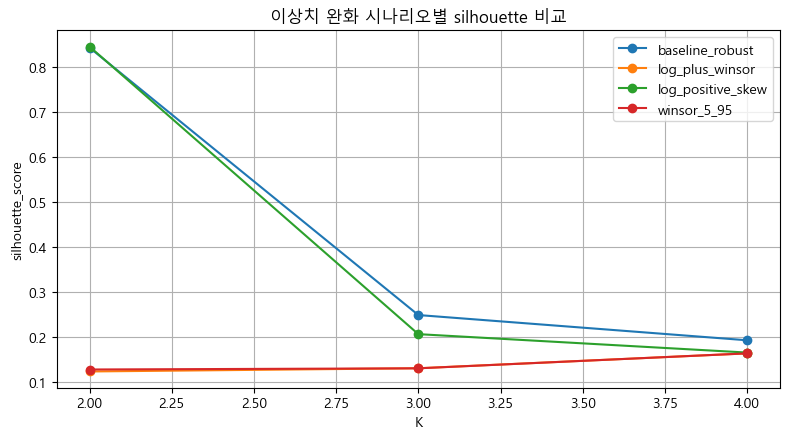


### 이상치 완화 실험 요약

- 로그 변환 적용 변수: franchise_ratio_recent4_mean
- 전체 시나리오 중 최고 실루엣 조합: `log_positive_skew` / `k=2` / `0.8462`
- 현재 기본 모델(`robust`, `k=2`)과 비교해 성능 차이가 크지 않다면, 원래 모델이 이상치에 과도하게 끌려간 결과는 아닐 가능성이 높다.
- 반대로 특정 전처리에서 실루엣이 뚜렷하게 올라가면, 최종 보고서에서 해당 변수의 이상치 민감성을 별도 한계로 언급하는 것이 좋다.


output\outlier_mitigation_experiment.csv
output\outlier_skewness_table.csv


In [155]:
outlier_base = dong_feature[final_features].copy()
outlier_base = outlier_base.replace([np.inf, -np.inf], np.nan)
outlier_base = outlier_base.fillna(outlier_base.median(numeric_only=True))

skew_table = outlier_base.skew(numeric_only=True).sort_values(ascending=False)
positive_skew_features = [
    col for col in outlier_base.columns
    if outlier_base[col].min() >= 0 and skew_table.get(col, 0) >= 1.0
]


def winsorize_df(data, lower=0.05, upper=0.95):
    clipped = data.copy()
    for col in clipped.columns:
        low = clipped[col].quantile(lower)
        high = clipped[col].quantile(upper)
        clipped[col] = clipped[col].clip(lower=low, upper=high)
    return clipped


def log_transform_selected(data, cols):
    transformed = data.copy()
    for col in cols:
        transformed[col] = np.log1p(transformed[col])
    return transformed

scenario_frames = {
    'baseline_robust': outlier_base,
    'winsor_5_95': winsorize_df(outlier_base, 0.05, 0.95),
    'log_positive_skew': log_transform_selected(outlier_base, positive_skew_features),
    'log_plus_winsor': winsorize_df(log_transform_selected(outlier_base, positive_skew_features), 0.05, 0.95)
}

outlier_rows = []
for scenario_name, scenario_df in scenario_frames.items():
    scenario_scaled = RobustScaler().fit_transform(scenario_df)
    for k in [2, 3, 4]:
        model = KMeans(n_clusters=k, random_state=42, n_init=20)
        labels = model.fit_predict(scenario_scaled)
        outlier_rows.append({
            'scenario': scenario_name,
            'k': k,
            'silhouette_score': silhouette_score(scenario_scaled, labels),
            'calinski_harabasz_score': calinski_harabasz_score(scenario_scaled, labels),
            'davies_bouldin_score': davies_bouldin_score(scenario_scaled, labels),
            'cluster_sizes': pd.Series(labels).value_counts().sort_index().to_dict()
        })

outlier_compare_df = pd.DataFrame(outlier_rows).sort_values(['scenario', 'k'])
display(pd.DataFrame({'skewness': skew_table}))
print('로그 변환 적용 변수:', positive_skew_features)
display(outlier_compare_df)

plt.figure(figsize=(8, 4.5))
for scenario_name, temp_df in outlier_compare_df.groupby('scenario'):
    plt.plot(temp_df['k'], temp_df['silhouette_score'], marker='o', label=scenario_name)
plt.title('이상치 완화 시나리오별 silhouette 비교')
plt.xlabel('K')
plt.ylabel('silhouette_score')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

best_outlier_row = outlier_compare_df.sort_values('silhouette_score', ascending=False).iloc[0]
outlier_md = f"""
### 이상치 완화 실험 요약

- 로그 변환 적용 변수: {', '.join(positive_skew_features) if positive_skew_features else '없음'}
- 전체 시나리오 중 최고 실루엣 조합: `{best_outlier_row['scenario']}` / `k={int(best_outlier_row['k'])}` / `{best_outlier_row['silhouette_score']:.4f}`
- 현재 기본 모델(`robust`, `k=2`)과 비교해 성능 차이가 크지 않다면, 원래 모델이 이상치에 과도하게 끌려간 결과는 아닐 가능성이 높다.
- 반대로 특정 전처리에서 실루엣이 뚜렷하게 올라가면, 최종 보고서에서 해당 변수의 이상치 민감성을 별도 한계로 언급하는 것이 좋다.
"""
display(Markdown(outlier_md))

outlier_compare_df.to_csv(OUTPUT_DIR / 'outlier_mitigation_experiment.csv', index=False, encoding='utf-8-sig')
pd.DataFrame({'feature': skew_table.index, 'skewness': skew_table.values}).to_csv(
    OUTPUT_DIR / 'outlier_skewness_table.csv', index=False, encoding='utf-8-sig'
)
print(OUTPUT_DIR / 'outlier_mitigation_experiment.csv')
print(OUTPUT_DIR / 'outlier_skewness_table.csv')

In [157]:
xgboost_file = dong_feature[[
    'gu', 'adm_dong_nm', 'land_price_growth_final',
    'transaction_growth_final',
    'mkt_vital_balance',
    'franchise_ratio_recent4_mean',
    'franchise_ratio_change',
    'bus_total_growth',
    'new_corp_growth',
    'external_inflow_log_recent',
    'close_rate_recent_final',
    'open_rate_recent_final']]

non_target_dongs_0 = ['태평2동', '태평3동', '태평4동', '분당동', '수내3동', '정자동', '정자2동', '정자3동', '서현2동', '이매2동', '야탑3동', '삼평동', '금곡동', '구미1동', '구미동']
target_dongs_1 = ['신흥2동', '산성동', '시흥동', '중앙동', '정자1동', '서현1동']
target_dongs_2 = ['위례동', '고등동', '성남동', '금광1동', '금광2동', '수내1동', '야탑1동', '판교동', '백현동', '운중동']
non_target_dongs_3 = ['신흥1동', '신흥3동', '태평1동', '수진1동', '수진2동', '단대동', '양지동', '복정동', '신촌동', '은행1동', '은행2동', '상대원1동', '상대원2동', '상대원3동', '하대원동', '도촌동', '수내2동', '이매1동', '야탑2동']

xgboost_file['cluster'] = None

xgboost_file.loc[xgboost_file['adm_dong_nm'].isin(non_target_dongs_0), 'cluster'] = 0
xgboost_file.loc[xgboost_file['adm_dong_nm'].isin(target_dongs_1), 'cluster'] = 1
xgboost_file.loc[xgboost_file['adm_dong_nm'].isin(target_dongs_2), 'cluster'] = 2
xgboost_file.loc[xgboost_file['adm_dong_nm'].isin(non_target_dongs_3), 'cluster'] = 3

xgboost_file['gentrification_risk'] = None

xgboost_file.loc[xgboost_file['adm_dong_nm'].isin(target_dongs_1), 'gentrification_risk'] = 1
xgboost_file.loc[xgboost_file['adm_dong_nm'].isin(target_dongs_2), 'gentrification_risk'] = 1

xgboost_file.loc[xgboost_file['adm_dong_nm'].isin(non_target_dongs_0), 'gentrification_risk'] = 0
xgboost_file.loc[xgboost_file['adm_dong_nm'].isin(non_target_dongs_3), 'gentrification_risk'] = 0

xgboost_file.to_csv('for_xgboost_file_0.csv', index=False)